# Fair Bank Marketing System: Detecting and Mitigating Socioeconomic Bias in AI-Driven Financial Product Targeting
---
**Module:** M515A — Ethical Issues for AI  
**Dataset:** Bank Marketing Dataset (Kaggle)  
**Kaggle Link:** https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset  
**Sensitive Attribute:** Education Level (0 = High/Tertiary, 1 = Low/Primary+Secondary)  
**Target Variable:** deposit (0 = No Subscription, 1 = Subscribed)  
**ML Task:** Binary Classification with Fairness Constraints  
**Student:** Om Patil | GH: 0000000000000  

---

## Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print("All libraries loaded successfully")

All libraries loaded successfully


---
## Section 1: Problem Statement

A Portuguese bank conducts telephone marketing campaigns to sell a financial
product called a term deposit — a fixed-period savings account that earns
guaranteed interest. The bank uses an AI system to predict which customers
are likely to subscribe, determining who receives a phone call and who is
excluded from the campaign entirely.

This project investigates whether the AI system discriminates against
customers with lower education levels — a direct proxy for socioeconomic
status. Customers with only primary or secondary education (Low Education)
may be systematically predicted as non-subscribers even when their financial
profile is identical to university-educated customers (High Education).

This project integrates three analytical frameworks:

1. Fairness Pipeline: Standard ML fairness analysis using FPR, FNR, FDR,
   FOR metrics and three discrimination types from the professor's
   Discrimination Lecture 2.

2. Similarity Analysis: Jaccard and Cosine Similarity from Prof. Babaei's
   Data Mining B141 lecture to show that similar customers receive different
   predictions based solely on education level.

3. Fair Influence Maximization: TCIM-Budget algorithm from the professor's
   Influence Maximization lecture to ensure the marketing campaign reaches
   both education groups proportionally.

**Why it matters:**

- Financial Harm: Low Education customers excluded from term deposit offers
  miss guaranteed savings returns, widening the wealth gap.
- Legal Risk: Education-based financial discrimination violates equal access
  to financial services legislation.
- Ethical Risk: Violates Justice and Fairness principle (Jobin et al., 2019).
- Social Impact: AI reinforces existing socioeconomic inequality.

**Data source:**  
Bank Marketing Dataset, Kaggle:  
https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset


---
## Phase 1: Data Loading

In [3]:
# Load the bank marketing dataset
df_raw = pd.read_csv('bank.csv')

print(f"Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nColumn names: {df_raw.columns.tolist()}")
df_raw.head(5)

Dataset loaded: 11,162 rows x 17 columns

Column names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
# Dataset info and statistics
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df_raw.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### Column Dictionary

| Column | Description | Type | Role |
|---|---|---|---|
| **age** | Customer age in years | int | Feature |
| **job** | Type of job | categorical | Feature |
| **marital** | Marital status | categorical | Feature |
| **education** | Education level (primary/secondary/tertiary) | categorical | **Sensitive Source** |
| **default** | Has credit in default? (yes/no) | binary | Feature |
| **balance** | Average yearly balance in euros | int | Feature |
| **housing** | Has housing loan? (yes/no) | binary | Feature |
| **loan** | Has personal loan? (yes/no) | binary | Feature |
| **contact** | Contact communication type | categorical | Feature |
| **day** | Last contact day of month | int | Feature |
| **month** | Last contact month | categorical | Feature |
| **duration** | Last contact duration in seconds | int | Feature |
| **campaign** | Number of contacts in this campaign | int | Feature |
| **pdays** | Days since last contact from previous campaign | int | Feature |
| **previous** | Number of contacts before this campaign | int | Feature |
| **poutcome** | Outcome of previous campaign | categorical | Feature |
| **deposit** | Has the client subscribed? (yes/no) | binary | **Target Variable** |

**Sensitive Attribute:**  
EduGroup derived from education:
- High Education (Tertiary/University) = 0  
- Low Education (Primary + Secondary) = 1


---
## Phase 2: Data Cleaning

In [6]:
# Step 1: Missing values check
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nTotal missing: {df_raw.isnull().sum().sum()}")
print("No missing values — dataset is clean")

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total missing: 0
No missing values — dataset is clean


In [7]:
# Step 2: Duplicate check
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print("No duplicates found")

Duplicate rows: 0
No duplicates found


In [8]:
# Step 3: Education distribution and remove unknown
print("Education distribution (raw):")
print(df_raw['education'].value_counts())

df = df_raw[df_raw['education'] != 'unknown'].copy()
df = df.reset_index(drop=True)
print(f"\nAfter removing unknown education: {len(df):,} rows")
print("\nEducation distribution (clean):")
print(df['education'].value_counts())

Education distribution (raw):
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

After removing unknown education: 10,665 rows

Education distribution (clean):
education
secondary    5476
tertiary     3689
primary      1500
Name: count, dtype: int64


=== TARGET VARIABLE: deposit ===
deposit_binary
0    5628
1    5037
Name: count, dtype: int64

Subscription Rate: 47.23%


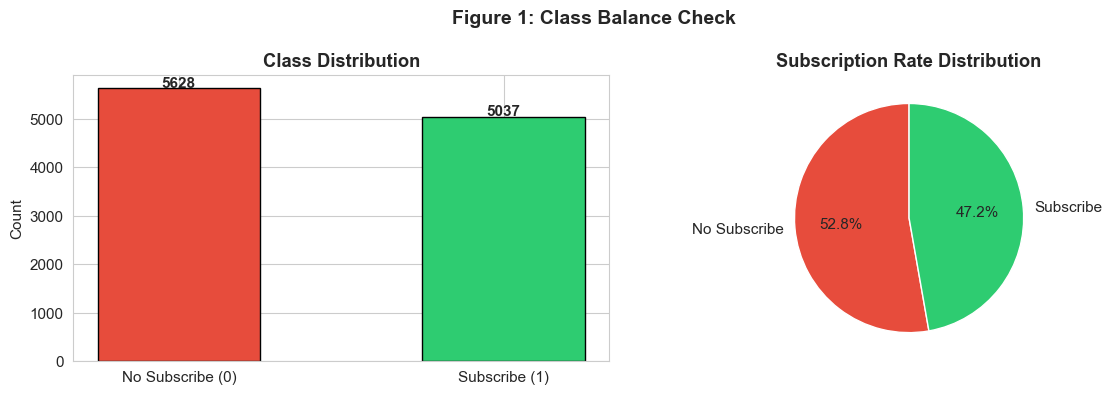

Class ratio: 1.12:1 — nearly balanced dataset


In [9]:
# Step 4: Create binary target variable
df['deposit_binary'] = (df['deposit'] == 'yes').astype(int)

print("=== TARGET VARIABLE: deposit ===")
counts = df['deposit_binary'].value_counts()
print(counts)
print(f"\nSubscription Rate: {df['deposit_binary'].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Subscribe (0)','Subscribe (1)'], counts.values,
             color=['#E74C3C','#2ECC71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Subscribe','Subscribe'],
             autopct='%1.1f%%', colors=['#E74C3C','#2ECC71'], startangle=90)
axes[1].set_title('Subscription Rate Distribution', fontweight='bold')

plt.suptitle('Figure 1: Class Balance Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Class ratio: {counts[0]/counts[1]:.2f}:1 — nearly balanced dataset")

---
## Phase 3: Exploratory Data Analysis

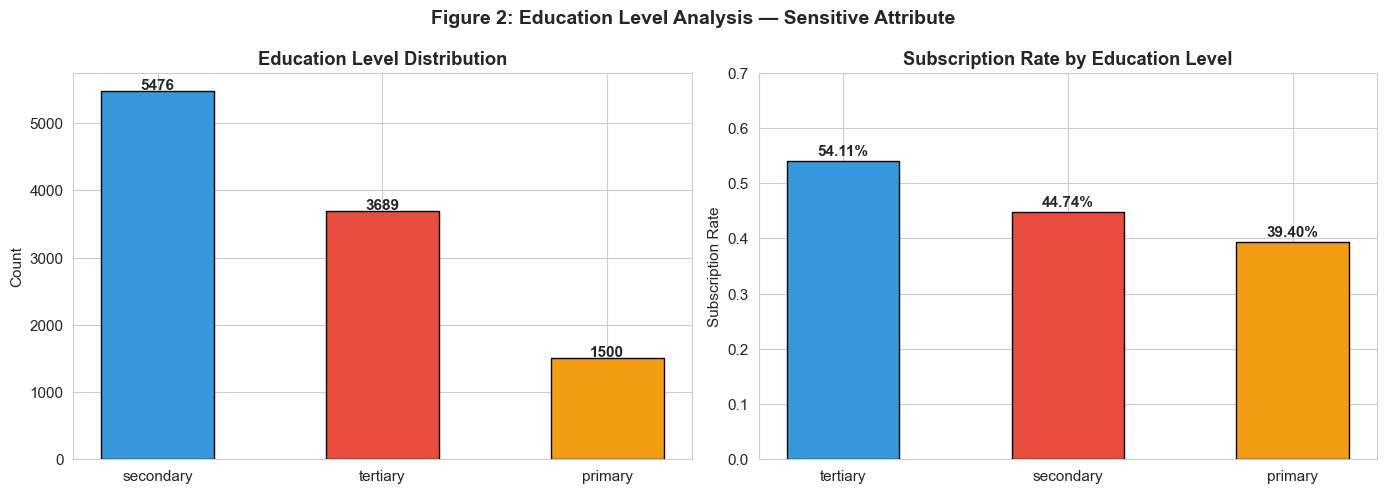

=== SUBSCRIPTION RATE BY EDUCATION ===
education
tertiary     0.5411
secondary    0.4474
primary      0.3940
Name: deposit_binary, dtype: float64

Gap Tertiary vs Primary: 14.71%


In [10]:
# Education distribution and subscription rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_counts = df['education'].value_counts()
axes[0].bar(edu_counts.index, edu_counts.values,
             color=['#3498DB','#E74C3C','#F39C12'], edgecolor='black', width=0.5)
axes[0].set_title('Education Level Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(edu_counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

sub_by_edu = df.groupby('education')['deposit_binary'].mean().reindex(
    ['tertiary','secondary','primary'])
bars = axes[1].bar(sub_by_edu.index, sub_by_edu.values,
                    color=['#3498DB','#E74C3C','#F39C12'], edgecolor='black', width=0.5)
axes[1].set_title('Subscription Rate by Education Level', fontweight='bold')
axes[1].set_ylabel('Subscription Rate')
axes[1].set_ylim(0, 0.70)
for bar, val in zip(bars, sub_by_edu.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.01, f'{val:.2%}',
                  ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Figure 2: Education Level Analysis — Sensitive Attribute',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== SUBSCRIPTION RATE BY EDUCATION ===")
print(sub_by_edu.round(4))
print(f"\nGap Tertiary vs Primary: {sub_by_edu['tertiary']-sub_by_edu['primary']:.2%}")

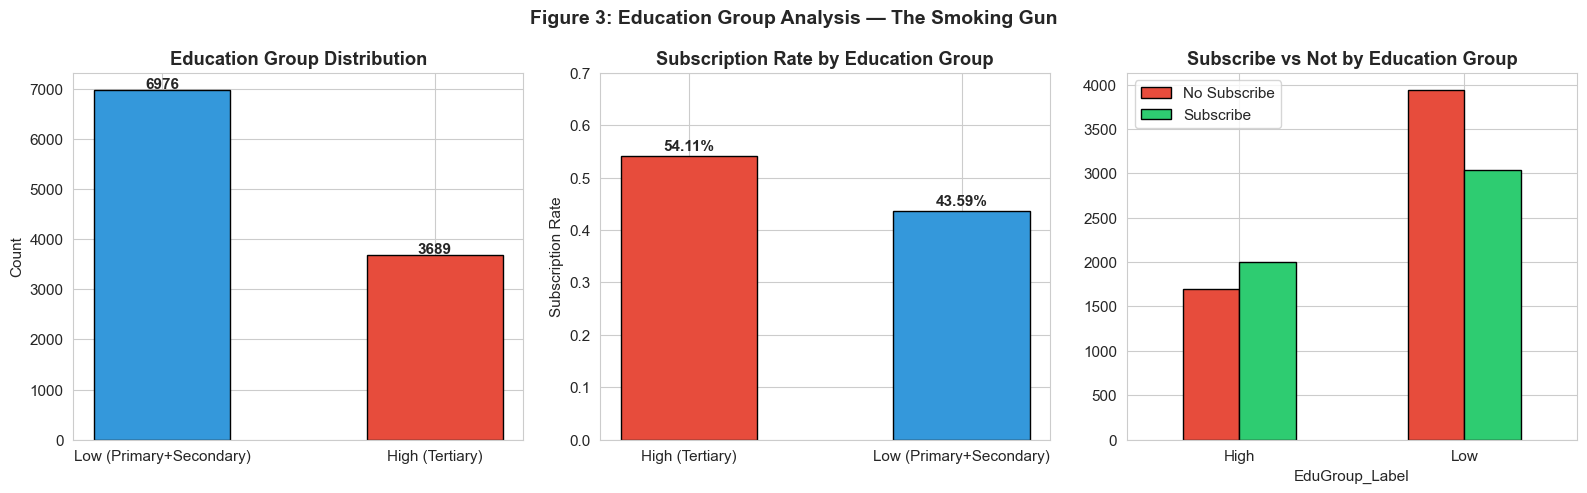

=== EDUCATION GROUP SUMMARY ===
High Education (Tertiary):        3,689 customers
Low Education (Primary+Secondary): 6,976 customers

Subscription Rate:
  High Education: 54.11%
  Low Education:  43.59%
  Gap:            10.51%


In [11]:
# EduGroup binary split analysis
df['EduGroup'] = df['education'].apply(
    lambda x: 0 if x == 'tertiary' else 1)
df['EduGroup_Label'] = df['EduGroup'].map({0:'High (Tertiary)', 1:'Low (Primary+Secondary)'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Group counts
eg_counts = df['EduGroup_Label'].value_counts()
axes[0].bar(eg_counts.index, eg_counts.values,
             color=['#3498DB','#E74C3C'], edgecolor='black', width=0.5)
axes[0].set_title('Education Group Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(eg_counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

# Subscription rate by group
sub_by_group = df.groupby('EduGroup_Label')['deposit_binary'].mean()
bars2 = axes[1].bar(sub_by_group.index, sub_by_group.values,
                     color=['#E74C3C','#3498DB'], edgecolor='black', width=0.5)
axes[1].set_title('Subscription Rate by Education Group', fontweight='bold')
axes[1].set_ylabel('Subscription Rate')
axes[1].set_ylim(0, 0.70)
for bar, val in zip(bars2, sub_by_group.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.01, f'{val:.2%}',
                  ha='center', fontweight='bold')

# Stacked bar
cross = df.groupby(['EduGroup_Label','deposit_binary']).size().unstack()
cross.plot(kind='bar', ax=axes[2],
            color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[2].set_title('Subscribe vs Not by Education Group', fontweight='bold')
axes[2].set_xticklabels(['High','Low'], rotation=0)
axes[2].legend(['No Subscribe','Subscribe'])

plt.suptitle('Figure 3: Education Group Analysis — The Smoking Gun',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== EDUCATION GROUP SUMMARY ===")
print(f"High Education (Tertiary):        {(df['EduGroup']==0).sum():,} customers")
print(f"Low Education (Primary+Secondary): {(df['EduGroup']==1).sum():,} customers")
print(f"\nSubscription Rate:")
print(f"  High Education: {df[df['EduGroup']==0]['deposit_binary'].mean():.2%}")
print(f"  Low Education:  {df[df['EduGroup']==1]['deposit_binary'].mean():.2%}")
print(f"  Gap:            {df[df['EduGroup']==0]['deposit_binary'].mean()-df[df['EduGroup']==1]['deposit_binary'].mean():.2%}")

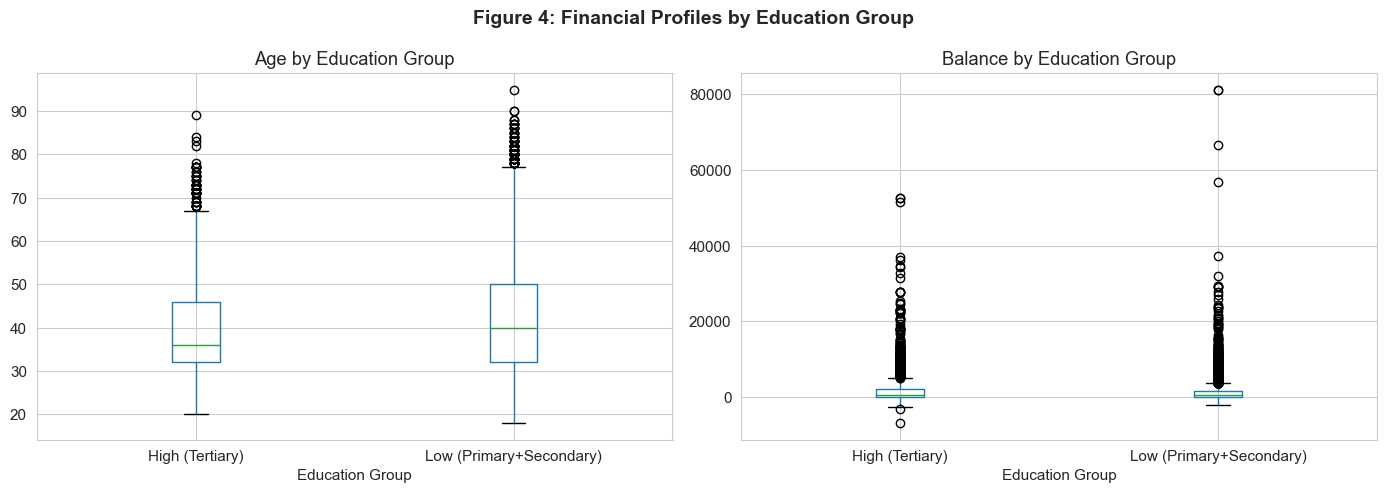

Age and Balance by Education Group:
                           age  balance
EduGroup_Label                         
High (Tertiary)          39.51  1845.87
Low (Primary+Secondary)  41.84  1345.19


In [12]:
# Age and Balance distributions by Education Group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='age', by='EduGroup_Label', ax=axes[0])
axes[0].set_title('Age Distribution by Education Group', fontweight='bold')
axes[0].set_xlabel('Education Group')
plt.sca(axes[0]); plt.title('Age by Education Group')

df.boxplot(column='balance', by='EduGroup_Label', ax=axes[1])
axes[1].set_title('Balance Distribution by Education Group', fontweight='bold')
axes[1].set_xlabel('Education Group')
plt.sca(axes[1]); plt.title('Balance by Education Group')

plt.suptitle('Figure 4: Financial Profiles by Education Group',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Age and Balance by Education Group:")
print(df.groupby('EduGroup_Label')[['age','balance']].mean().round(2))

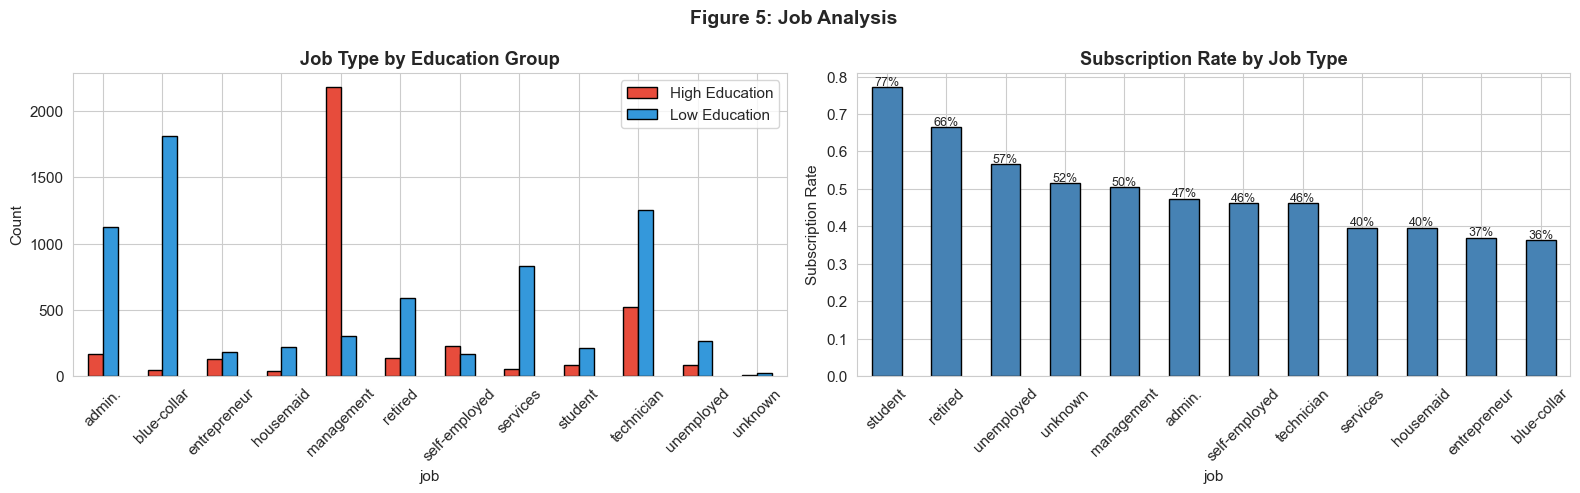

In [13]:
# Job distribution by education group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

job_edu = df.groupby(['job','EduGroup_Label']).size().unstack(fill_value=0)
job_edu.plot(kind='bar', ax=axes[0],
              color=['#E74C3C','#3498DB'], edgecolor='black')
axes[0].set_title('Job Type by Education Group', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['High Education','Low Education'])

sub_by_job = df.groupby('job')['deposit_binary'].mean().sort_values(ascending=False)
sub_by_job.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Subscription Rate by Job Type', fontweight='bold')
axes[1].set_ylabel('Subscription Rate')
axes[1].tick_params(axis='x', rotation=45)
for i, val in enumerate(sub_by_job.values):
    axes[1].text(i, val+0.005, f'{val:.0%}', ha='center', fontsize=9)

plt.suptitle('Figure 5: Job Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

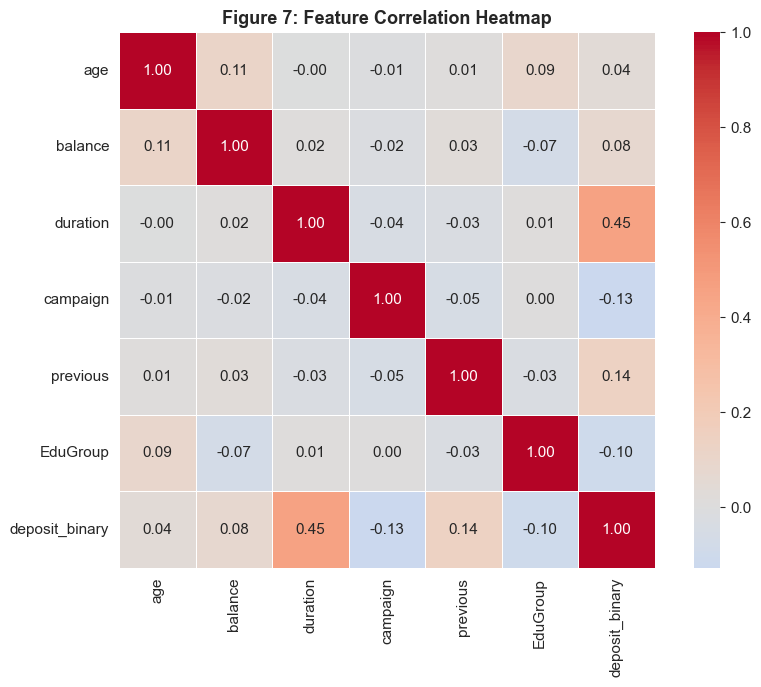

Correlation with deposit_binary:
deposit_binary    1.000000
duration          0.454909
previous          0.138415
balance           0.077669
age               0.036501
EduGroup         -0.100180
campaign         -0.128153
Name: deposit_binary, dtype: float64


In [14]:
# Correlation heatmap
df['Gender_enc'] = 0
le_temp = LabelEncoder()
corr_df = df.copy()
for col in ['job','marital','education','default','housing',
            'loan','contact','month','poutcome']:
    corr_df[f'{col}_num'] = le_temp.fit_transform(corr_df[col])

corr_cols = ['age','balance','duration','campaign','previous',
             'EduGroup','deposit_binary']
plt.figure(figsize=(9, 7))
corr = corr_df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Figure 7: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with deposit_binary:")
print(corr['deposit_binary'].sort_values(ascending=False))

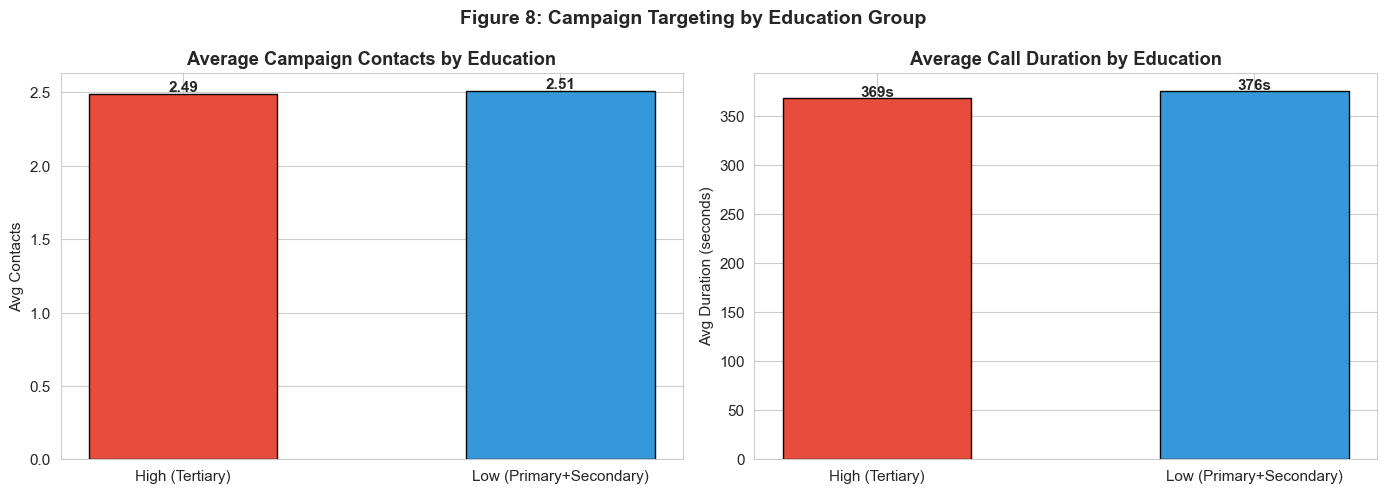

In [15]:
# Campaign contacts by education group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contact_by_edu = df.groupby('EduGroup_Label')['campaign'].mean()
axes[0].bar(contact_by_edu.index, contact_by_edu.values,
             color=['#E74C3C','#3498DB'], edgecolor='black', width=0.5)
axes[0].set_title('Average Campaign Contacts by Education', fontweight='bold')
axes[0].set_ylabel('Avg Contacts')
for i, v in enumerate(contact_by_edu.values):
    axes[0].text(i, v+0.02, f'{v:.2f}', ha='center', fontweight='bold')

duration_by_edu = df.groupby('EduGroup_Label')['duration'].mean()
axes[1].bar(duration_by_edu.index, duration_by_edu.values,
             color=['#E74C3C','#3498DB'], edgecolor='black', width=0.5)
axes[1].set_title('Average Call Duration by Education', fontweight='bold')
axes[1].set_ylabel('Avg Duration (seconds)')
for i, v in enumerate(duration_by_edu.values):
    axes[1].text(i, v+2, f'{v:.0f}s', ha='center', fontweight='bold')

plt.suptitle('Figure 8: Campaign Targeting by Education Group',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2: Ethical Concerns

### 2.1 Five Principles of AI Ethics (Jobin et al., 2019)

According to Jobin et al. (2019), five core principles guide ethical AI.
Each is applied to this banking AI system:

**Non-maleficence:** When an AI system excludes Low Education customers from
term deposit offers, they miss guaranteed savings returns. This causes direct
and measurable financial harm — the wealth gap between socioeconomic classes
widens as a consequence of algorithmic exclusion.

**Accountability:** When the AI systematically skips Low Education customers,
responsibility must be assigned — to the bank deploying the system, the
algorithm developer, or the marketing manager who relied on AI-generated lists
without independent verification.

**Transparency:** Customers who were never called have no way to know they were
excluded by an algorithm, nor can they challenge a decision made by a black-box
model.

**Justice and Fairness:** Every customer deserves equal consideration for
financial products regardless of their education level. The algorithm must
not encode socioeconomic class into financial access decisions.

**Human Rights:** Equal access to financial services and savings products
is a fundamental economic right. An AI that denies this access based on
education level — a proxy for socioeconomic class — violates this right.

---

### 2.2 Three Types of Discrimination Tested

**Disparate Treatment**

Occurs when two customers with identical financial profiles receive different
subscription predictions solely because of their education level.

$$P(\text{Subscribe} \mid \text{Low Edu}, Q) < P(\text{Subscribe} \mid \text{High Edu}, Q)$$

Where Q = same qualification group (same AgeGroup + BalanceGroup).

**Disparate Impact**

Occurs when overall predicted subscription rates differ significantly across
education groups. Tested using the EEOC Four-Fifths Rule (29 C.F.R. Section 1607):

$$\text{DIR} = \frac{\text{Low Education Predicted Subscribe Rate}}{\text{High Education Predicted Subscribe Rate}}$$

$$\text{If DIR} < 0.80 \Rightarrow \text{Disparate Impact EXISTS}$$

**Disparate Mistreatment**

Occurs when error rates differ significantly across groups. From professor's
Discrimination Lecture 2 (COMPAS case study formulas):

$$FPR = \frac{FP}{FP + TN} \quad FNR = \frac{FN}{FN + TP} \quad FDR = \frac{FP}{FP + TP} \quad FOR = \frac{FN}{FN + TN}$$

$$\text{If } |FOR_{High} - FOR_{Low}| > 0.05 \Rightarrow \text{Disparate Mistreatment CONFIRMED}$$

---

### 2.3 Influence Maximization Context

From professor's Influence Maximization lecture, even after fixing the AI model,
the bank's marketing campaign must also be made fair. The bank selects SEED
customers to call first. These seeds influence others through word-of-mouth.

**Measure of Unfairness (professor's exact formula):**

$$\text{Unfairness} = \max_{i,j \in \{1,2,...,k\}} \left| \frac{f_\tau(S; V_i, G)}{|V_i|} - \frac{f_\tau(S; V_j, G)}{|V_j|} \right|$$

Where $f_\tau(S; V, G) = \mathbb{E}\left[\sum_{v \in V, t_v \geq 0} \mathbf{1}(t_v \leq \tau)\right]$

**Fair TCIM-Budget (professor's exact formula):**

$$\max_{S \subseteq V} \sum_{i=1}^{k} f_\tau(S; V_i, G) \quad \text{subject to } |S| \leq B$$

$$\text{and} \quad \max_{i,j} \left| \frac{f_\tau(S; V_i, G)}{|V_i|} - \frac{f_\tau(S; V_j, G)}{|V_j|} \right| \leq c$$

---

### 2.4 Similarity and Distance Context

From Prof. Babaei's Data Mining B141 lecture, we use two similarity measures
to prove that similar customers receive different predictions:

$$\text{Jaccard Similarity: } JSim(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

$$\text{Cosine Similarity: } Cos(A,B) = \frac{A \cdot B}{|A| \times |B|}$$

---

### 2.5 Reweighing Formula

$$w = \frac{P(\text{education}) \times P(\text{outcome})}{P(\text{education, outcome})}$$


---
## Phase 4: Feature Engineering

### Feature Engineering Formulas

**EduGroup** — Binary sensitive attribute:
$$\text{EduGroup} = 0 \text{ if education = tertiary (High)}, \quad 1 \text{ if primary or secondary (Low)}$$

**AgeGroup** — For Disparate Treatment analysis:
$$\text{AgeGroup} = \begin{cases} 1 & \text{Young (Age} \leq 35) \\ 2 & \text{Middle (35 < Age} \leq 55) \\ 3 & \text{Senior (Age} > 55) \end{cases}$$

**BalanceGroup** — For Disparate Treatment analysis:
$$\text{BalanceGroup} = \begin{cases} 1 & \text{Low (Balance} \leq 500) \\ 2 & \text{Middle (500 < Balance} \leq 2000) \\ 3 & \text{High (Balance} > 2000) \end{cases}$$

All categorical columns encoded using **LabelEncoder**: text categories converted to integers (0, 1, 2, ..., n).


In [16]:
# Create all engineered features
# AgeGroup
df['AgeGroup'] = pd.cut(df['age'], bins=[0,35,55,100],
                         labels=[1,2,3]).astype(int)

# BalanceGroup
df['BalanceGroup'] = pd.cut(df['balance'],
                             bins=[-10000,500,2000,100000],
                             labels=[1,2,3])
df['BalanceGroup'] = df['BalanceGroup'].cat.add_categories([0]).fillna(0).astype(int)

# Encode all categorical columns
le = LabelEncoder()
for col in ['job','marital','education','default','housing',
            'loan','contact','month','poutcome']:
    df[f'{col}_enc'] = le.fit_transform(df[col])

print("=== FEATURES CREATED ===")
print(f"EduGroup:     {df['EduGroup'].value_counts().to_dict()}")
print(f"              (0=High/Tertiary, 1=Low/Primary+Secondary)")
print(f"AgeGroup:     {df['AgeGroup'].value_counts().sort_index().to_dict()}")
print(f"              (1=Young<=35, 2=Middle 35-55, 3=Senior>55)")
print(f"BalanceGroup: {df['BalanceGroup'].value_counts().sort_index().to_dict()}")
print(f"              (1=Low<=500, 2=Mid 500-2000, 3=High>2000)")
print(f"Categorical columns encoded: job, marital, education, default,")
print(f"housing, loan, contact, month, poutcome")

=== FEATURES CREATED ===
EduGroup:     {1: 6976, 0: 3689}
              (0=High/Tertiary, 1=Low/Primary+Secondary)
AgeGroup:     {1: 4246, 2: 5045, 3: 1374}
              (1=Young<=35, 2=Middle 35-55, 3=Senior>55)
BalanceGroup: {1: 5136, 2: 3224, 3: 2305}
              (1=Low<=500, 2=Mid 500-2000, 3=High>2000)
Categorical columns encoded: job, marital, education, default,
housing, loan, contact, month, poutcome


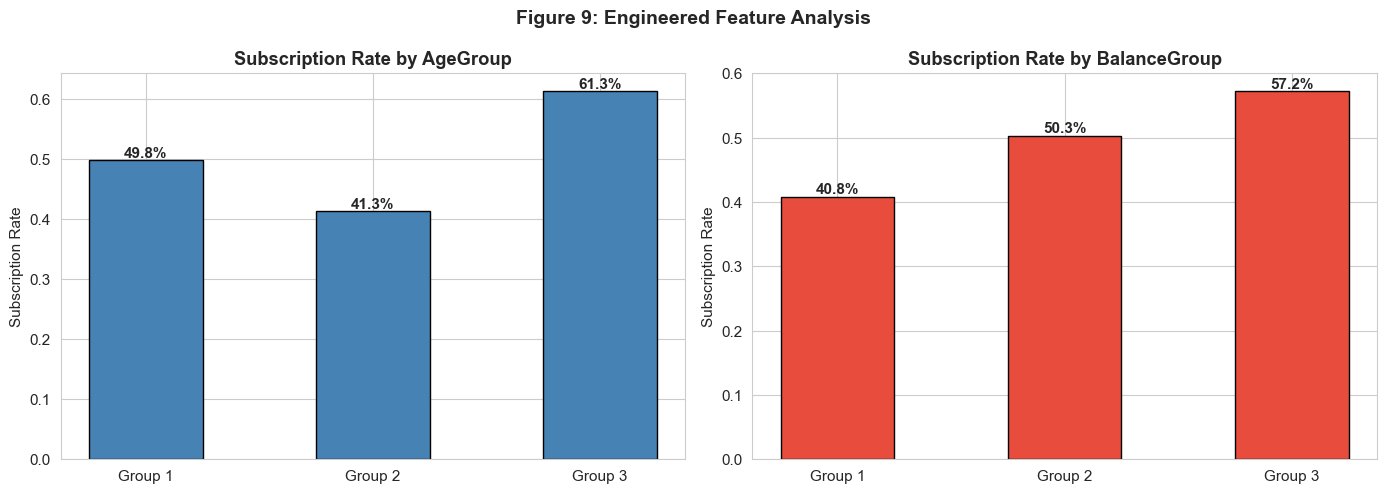

In [17]:
# Feature visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AgeGroup subscription rate
ag_sub = df.groupby('AgeGroup')['deposit_binary'].mean()
axes[0].bar([f'Group {i}' for i in ag_sub.index], ag_sub.values,
             color='steelblue', edgecolor='black', width=0.5)
axes[0].set_title('Subscription Rate by AgeGroup', fontweight='bold')
axes[0].set_ylabel('Subscription Rate')
for i, val in enumerate(ag_sub.values):
    axes[0].text(i, val+0.005, f'{val:.1%}', ha='center', fontweight='bold')

# BalanceGroup subscription rate
bg_sub = df[df['BalanceGroup']>0].groupby('BalanceGroup')['deposit_binary'].mean()
axes[1].bar([f'Group {i}' for i in bg_sub.index], bg_sub.values,
             color='#E74C3C', edgecolor='black', width=0.5)
axes[1].set_title('Subscription Rate by BalanceGroup', fontweight='bold')
axes[1].set_ylabel('Subscription Rate')
for i, val in enumerate(bg_sub.values):
    axes[1].text(i, val+0.005, f'{val:.1%}', ha='center', fontweight='bold')

plt.suptitle('Figure 9: Engineered Feature Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 5: Data Preprocessing

In [18]:
# Define feature matrix and target
sensitive_attr = df['EduGroup'].copy()

feature_cols = ['age','job_enc','marital_enc','education_enc',
                'default_enc','balance','housing_enc','loan_enc',
                'contact_enc','day','month_enc','duration',
                'campaign','pdays','previous','poutcome_enc',
                'AgeGroup','BalanceGroup','EduGroup']

X = df[feature_cols].copy()
y = df['deposit_binary'].copy()

print(f"Feature Matrix X: {X.shape}")
print(f"Target Vector y:  {y.shape}")
print(f"Sensitive Attr:   {sensitive_attr.shape}")
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"Subscription Rate: {y.mean():.2%}")

Feature Matrix X: (10665, 19)
Target Vector y:  (10665,)
Sensitive Attr:   (10665,)

Features (19): ['age', 'job_enc', 'marital_enc', 'education_enc', 'default_enc', 'balance', 'housing_enc', 'loan_enc', 'contact_enc', 'day', 'month_enc', 'duration', 'campaign', 'pdays', 'previous', 'poutcome_enc', 'AgeGroup', 'BalanceGroup', 'EduGroup']

Target distribution:
deposit_binary
0    5628
1    5037
Name: count, dtype: int64
Subscription Rate: 47.23%


In [19]:
# Train/Test Split — 80/20 stratified
X_train, X_test, y_train, y_test, edu_train, edu_test = train_test_split(
    X, y, sensitive_attr,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== SPLIT SUMMARY ===")
print(f"Training set: {X_train.shape[0]:,} samples (80%)")
print(f"Test set:     {X_test.shape[0]:,} samples (20%)")
print(f"\nTrain Subscription Rate: {y_train.mean():.2%}")
print(f"Test  Subscription Rate: {y_test.mean():.2%}  (stratified)")
print(f"\nTest Education Group split:")
print(f"  High Education (Tertiary):        {(edu_test==0).sum():,}")
print(f"  Low Education  (Primary+Secondary): {(edu_test==1).sum():,}")

=== SPLIT SUMMARY ===
Training set: 8,532 samples (80%)
Test set:     2,133 samples (20%)

Train Subscription Rate: 47.23%
Test  Subscription Rate: 47.21%  (stratified)

Test Education Group split:
  High Education (Tertiary):        772
  Low Education  (Primary+Secondary): 1,361


In [20]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied")
print(f"Formula: z = (x - mean) / standard_deviation")
print(f"Training mean (post-scale): {X_train_scaled.mean():.6f}  (approx 0)")
print(f"Training std  (post-scale): {X_train_scaled.std():.6f}   (approx 1)")
print("\nScaler fit ONLY on training set — prevents data leakage")

StandardScaler applied
Formula: z = (x - mean) / standard_deviation
Training mean (post-scale): -0.000000  (approx 0)
Training std  (post-scale): 1.000000   (approx 1)

Scaler fit ONLY on training set — prevents data leakage


---
## Phase 6: Baseline Model Training
> No fairness constraints applied. This is the BIASED baseline model.


In [21]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {lr_acc:.4f}")
print(classification_report(y_test, lr_pred,
      target_names=['No Subscribe','Subscribe']))

=== LOGISTIC REGRESSION ===
Accuracy: 0.8008
              precision    recall  f1-score   support

No Subscribe       0.80      0.83      0.82      1126
   Subscribe       0.81      0.76      0.78      1007

    accuracy                           0.80      2133
   macro avg       0.80      0.80      0.80      2133
weighted avg       0.80      0.80      0.80      2133



In [22]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   max_depth=10, min_samples_split=5)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_pred,
      target_names=['No Subscribe','Subscribe']))

=== RANDOM FOREST ===
Accuracy: 0.8401
              precision    recall  f1-score   support

No Subscribe       0.87      0.82      0.84      1126
   Subscribe       0.81      0.86      0.84      1007

    accuracy                           0.84      2133
   macro avg       0.84      0.84      0.84      2133
weighted avg       0.84      0.84      0.84      2133



In [23]:
# Model comparison
comp_df = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest'],
    'Accuracy': [round(lr_acc,4), round(rf_acc,4)]
})
print("=== MODEL COMPARISON ===")
print(comp_df.to_string(index=False))

best_model = rf_model
best_pred  = rf_pred
best_acc   = rf_acc
print(f"\nSelected: Random Forest (Accuracy: {best_acc:.4f})")

=== MODEL COMPARISON ===
              Model  Accuracy
Logistic Regression    0.8008
      Random Forest    0.8401

Selected: Random Forest (Accuracy: 0.8401)


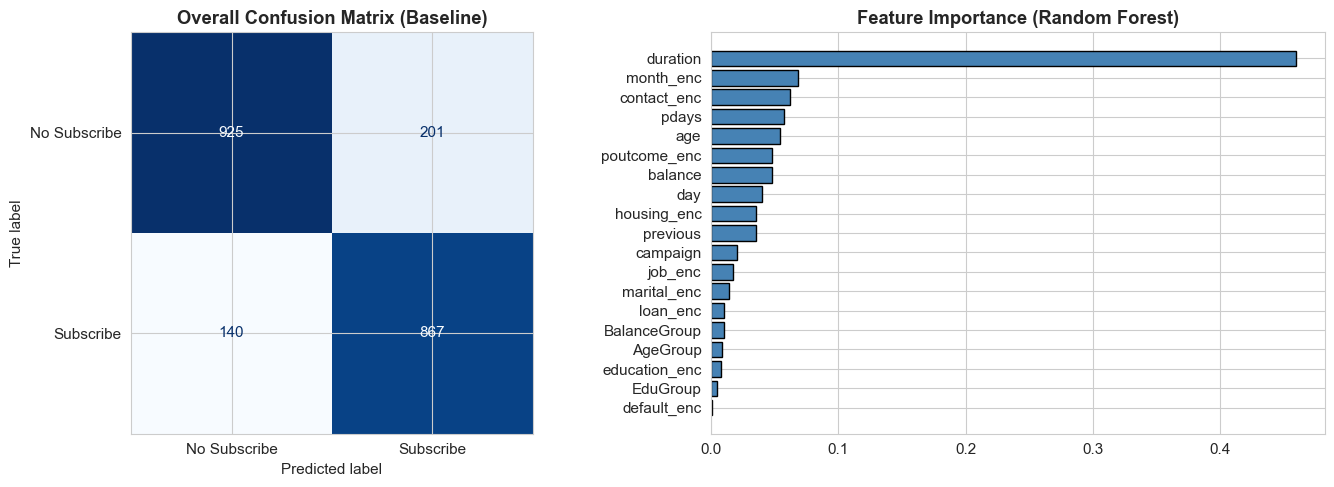

TN=925, FP=201, FN=140, TP=867
Overall Accuracy = (TP+TN)/(TP+TN+FP+FN)
= (867+925) / (867+925+201+140)
= 1792 / 2133
= 0.8401


In [24]:
# Overall confusion matrix and feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_overall = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm_overall,
    display_labels=['No Subscribe','Subscribe']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Overall Confusion Matrix (Baseline)', fontweight='bold')

fi = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)
axes[1].barh(fi['Feature'], fi['Importance'],
              color='steelblue', edgecolor='black')
axes[1].set_title('Feature Importance (Random Forest)', fontweight='bold')

plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_overall.ravel()
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")
print(f"Overall Accuracy = (TP+TN)/(TP+TN+FP+FN)")
print(f"= ({TP}+{TN}) / ({TP}+{TN}+{FP}+{FN})")
print(f"= {TP+TN} / {TP+TN+FP+FN}")
print(f"= {best_acc:.4f}")

---
## Phase 7: Bias Detection and Discrimination Analysis
> Splitting predictions by Education Group to detect socioeconomic discrimination.


In [25]:
# Split test set by Education Group
high_mask = (edu_test == 0).values
low_mask  = (edu_test == 1).values

y_test_arr  = y_test.values
y_test_high = y_test_arr[high_mask]
y_pred_high = best_pred[high_mask]
y_test_low  = y_test_arr[low_mask]
y_pred_low  = best_pred[low_mask]

print(f"High Education test samples: {high_mask.sum():,}")
print(f"Low Education test samples:  {low_mask.sum():,}")
print(f"\nHigh Edu actual subscription rate:    {y_test_high.mean():.2%}")
print(f"Low Edu actual subscription rate:     {y_test_low.mean():.2%}")
print(f"High Edu predicted subscription rate: {y_pred_high.mean():.2%}")
print(f"Low Edu predicted subscription rate:  {y_pred_low.mean():.2%}")

High Education test samples: 772
Low Education test samples:  1,361

High Edu actual subscription rate:    55.57%
Low Edu actual subscription rate:     42.47%
High Edu predicted subscription rate: 55.70%
Low Edu predicted subscription rate:  46.88%


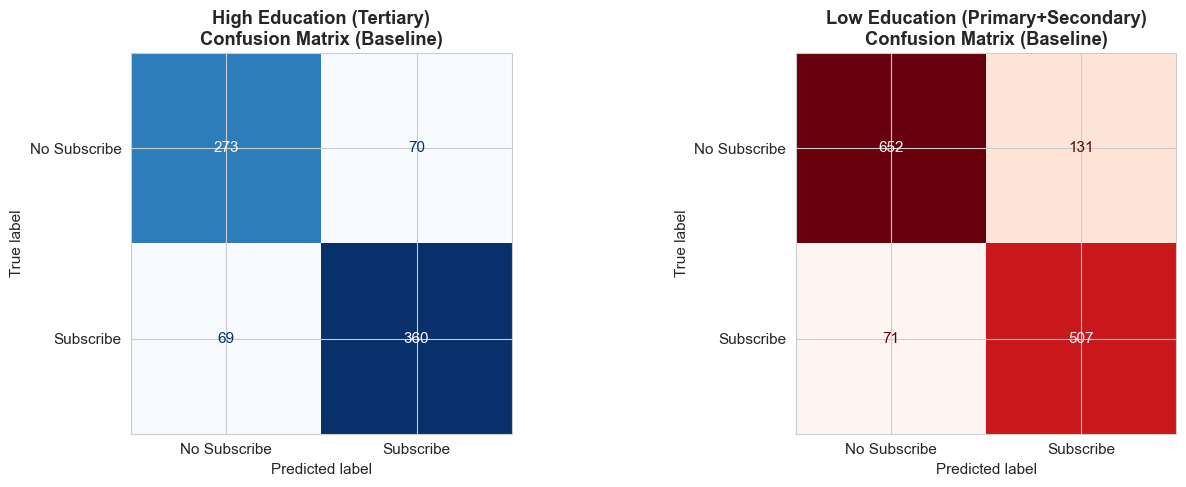

High Edu CM: TN=273, FP=70, FN=69, TP=360
Low Edu  CM: TN=652, FP=131, FN=71, TP=507


In [26]:
# Per-group confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_high = confusion_matrix(y_test_high, y_pred_high)
ConfusionMatrixDisplay(cm_high,
    display_labels=['No Subscribe','Subscribe']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('High Education (Tertiary)\nConfusion Matrix (Baseline)',
                   fontweight='bold')

cm_low = confusion_matrix(y_test_low, y_pred_low)
ConfusionMatrixDisplay(cm_low,
    display_labels=['No Subscribe','Subscribe']).plot(
    ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Low Education (Primary+Secondary)\nConfusion Matrix (Baseline)',
                   fontweight='bold')

plt.tight_layout()
plt.show()

TN_h, FP_h, FN_h, TP_h = cm_high.ravel()
TN_l, FP_l, FN_l, TP_l = cm_low.ravel()
print(f"High Edu CM: TN={TN_h}, FP={FP_h}, FN={FN_h}, TP={TP_h}")
print(f"Low Edu  CM: TN={TN_l}, FP={FP_l}, FN={FN_l}, TP={TP_l}")

### Fairness Metric Formulas
(Source: professor's Discrimination Lecture 2 — COMPAS case study calculations)

$$FPR = \frac{FP}{FP + TN} \quad FNR = \frac{FN}{FN + TP} \quad FDR = \frac{FP}{FP + TP} \quad FOR = \frac{FN}{FN + TN}$$


In [27]:
# Fairness metrics function
def calculate_fairness_metrics(y_true, y_pred, group_name):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    FPR = FP/(FP+TN) if (FP+TN)>0 else 0
    FNR = FN/(FN+TP) if (FN+TP)>0 else 0
    FDR = FP/(FP+TP) if (FP+TP)>0 else 0
    FOR = FN/(FN+TN) if (FN+TN)>0 else 0
    ACC = accuracy_score(y_true, y_pred)
    return {'Group':group_name,'TN':int(TN),'FP':int(FP),
            'FN':int(FN),'TP':int(TP),'FPR':round(FPR,4),
            'FNR':round(FNR,4),'FDR':round(FDR,4),
            'FOR':round(FOR,4),'ACC':round(ACC,4)}

print("Fairness metrics function defined")
print("\nFormulas from professor's Discrimination Lecture 2:")
print("  FPR = FP / (FP + TN)")
print("  FNR = FN / (FN + TP)")
print("  FDR = FP / (FP + TP)")
print("  FOR = FN / (FN + TN)")

Fairness metrics function defined

Formulas from professor's Discrimination Lecture 2:
  FPR = FP / (FP + TN)
  FNR = FN / (FN + TP)
  FDR = FP / (FP + TP)
  FOR = FN / (FN + TN)


In [28]:
# Step-by-step metric calculations
baseline_high = calculate_fairness_metrics(y_test_high, y_pred_high, 'High Education')
baseline_low  = calculate_fairness_metrics(y_test_low,  y_pred_low,  'Low Education')

TN_h=baseline_high['TN']; FP_h=baseline_high['FP']
FN_h=baseline_high['FN']; TP_h=baseline_high['TP']
TN_l=baseline_low['TN'];  FP_l=baseline_low['FP']
FN_l=baseline_low['FN'];  TP_l=baseline_low['TP']

print("=== STEP-BY-STEP CALCULATION — BASELINE ===")
print()
print("High Education (Tertiary):")
print(f"  FPR = {FP_h} / ({FP_h}+{TN_h}) = {FP_h}/{FP_h+TN_h} = {baseline_high['FPR']}")
print(f"  FNR = {FN_h} / ({FN_h}+{TP_h}) = {FN_h}/{FN_h+TP_h} = {baseline_high['FNR']}")
print(f"  FDR = {FP_h} / ({FP_h}+{TP_h}) = {FP_h}/{FP_h+TP_h} = {baseline_high['FDR']}")
print(f"  FOR = {FN_h} / ({FN_h}+{TN_h}) = {FN_h}/{FN_h+TN_h} = {baseline_high['FOR']}")
print()
print("Low Education (Primary+Secondary):")
print(f"  FPR = {FP_l} / ({FP_l}+{TN_l}) = {FP_l}/{FP_l+TN_l} = {baseline_low['FPR']}")
print(f"  FNR = {FN_l} / ({FN_l}+{TP_l}) = {FN_l}/{FN_l+TP_l} = {baseline_low['FNR']}")
print(f"  FDR = {FP_l} / ({FP_l}+{TP_l}) = {FP_l}/{FP_l+TP_l} = {baseline_low['FDR']}")
print(f"  FOR = {FN_l} / ({FN_l}+{TN_l}) = {FN_l}/{FN_l+TN_l} = {baseline_low['FOR']}")
print()
print("="*60)
print("       BASELINE FAIRNESS METRICS")
print("="*60)
print(f"{'Metric':<8} {'High':>10} {'Low':>10} {'Disparity':>12}")
print("-"*60)
for m in ['FPR','FNR','FDR','FOR','ACC']:
    h_val=baseline_high[m]; l_val=baseline_low[m]
    diff=abs(h_val-l_val)
    flag=" BIAS DETECTED" if diff>0.05 else ""
    print(f"{m:<8} {h_val:>10.4f} {l_val:>10.4f} {diff:>12.4f}{flag}")
print("="*60)

=== STEP-BY-STEP CALCULATION — BASELINE ===

High Education (Tertiary):
  FPR = 70 / (70+273) = 70/343 = 0.2041
  FNR = 69 / (69+360) = 69/429 = 0.1608
  FDR = 70 / (70+360) = 70/430 = 0.1628
  FOR = 69 / (69+273) = 69/342 = 0.2018

Low Education (Primary+Secondary):
  FPR = 131 / (131+652) = 131/783 = 0.1673
  FNR = 71 / (71+507) = 71/578 = 0.1228
  FDR = 131 / (131+507) = 131/638 = 0.2053
  FOR = 71 / (71+652) = 71/723 = 0.0982

       BASELINE FAIRNESS METRICS
Metric         High        Low    Disparity
------------------------------------------------------------
FPR          0.2041     0.1673       0.0368
FNR          0.1608     0.1228       0.0380
FDR          0.1628     0.2053       0.0425
FOR          0.2018     0.0982       0.1036 BIAS DETECTED
ACC          0.8199     0.8516       0.0317


### Disparate Impact Check

$$\text{DIR} = \frac{\text{Low Education Predicted Subscribe Rate}}{\text{High Education Predicted Subscribe Rate}}$$

$$\text{If DIR} < 0.80 \Rightarrow \text{Disparate Impact EXISTS}$$

Source: EEOC Four-Fifths Rule (29 C.F.R. Section 1607, 1978),
referenced in professor's Discrimination Lecture 2.


In [29]:
# Disparate Impact Check
hr_high = y_pred_high.mean()
hr_low  = y_pred_low.mean()
DIR = hr_low / hr_high if hr_high > 0 else 0

print("=== DISPARATE IMPACT CHECK ===")
print()
print("Step 1: Calculate predicted subscription rates")
print(f"  High Edu Rate = {baseline_high['TP']} / {high_mask.sum()} = {hr_high:.4f} ({hr_high:.2%})")
print(f"  Low Edu Rate  = {baseline_low['TP']}  / {low_mask.sum()}  = {hr_low:.4f} ({hr_low:.2%})")
print()
print("Step 2: Calculate DIR")
print(f"  DIR = Low Rate / High Rate")
print(f"  DIR = {hr_low:.4f} / {hr_high:.4f} = {DIR:.4f}")
print()
print("Step 3: Apply EEOC Four-Fifths Rule threshold")
print(f"  If DIR < 0.80 -> Disparate Impact EXISTS")
print(f"  DIR = {DIR:.4f}")
print()
if DIR < 0.80:
    print(f"RESULT: DISPARATE IMPACT DETECTED (DIR = {DIR:.4f} < 0.80)")
    print(f"Low Education customers predicted to subscribe at {DIR:.2%} the rate of High Education")
else:
    print(f"No Disparate Impact (DIR = {DIR:.4f})")

=== DISPARATE IMPACT CHECK ===

Step 1: Calculate predicted subscription rates
  High Edu Rate = 360 / 772 = 0.5570 (55.70%)
  Low Edu Rate  = 507  / 1361  = 0.4688 (46.88%)

Step 2: Calculate DIR
  DIR = Low Rate / High Rate
  DIR = 0.4688 / 0.5570 = 0.8416

Step 3: Apply EEOC Four-Fifths Rule threshold
  If DIR < 0.80 -> Disparate Impact EXISTS
  DIR = 0.8416

No Disparate Impact (DIR = 0.8416)


### Disparate Treatment Check

Disparate Treatment occurs when two customers with identical financial profiles
(same AgeGroup + BalanceGroup) receive different predictions based solely on
education level.

$$P(\text{Subscribe} \mid \text{Low Edu}, Q) < P(\text{Subscribe} \mid \text{High Edu}, Q)$$

Where Q = same AgeGroup + same BalanceGroup.


In [30]:
# Disparate Treatment Check
test_copy = X_test.copy()
test_copy['y_pred']   = best_pred
test_copy['EduGroup'] = edu_test.values
test_copy['EduLabel'] = test_copy['EduGroup'].map({0:'High (Tertiary)',
                                                    1:'Low (Primary+Sec)'})
test_copy['AgeGroup_label'] = test_copy['AgeGroup'].map(
    {1:'Young(<=35)',2:'Middle(35-55)',3:'Senior(>55)'})
test_copy['BalGroup_label'] = test_copy['BalanceGroup'].map(
    {0:'Unknown',1:'Low(<=500)',2:'Mid(500-2k)',3:'High(>2k)'})

treatment = test_copy.groupby(
    ['AgeGroup_label','BalGroup_label','EduLabel'])['y_pred'].mean().unstack()

print("=== DISPARATE TREATMENT CHECK ===")
print("Predicted Subscribe Rate by AgeGroup + BalanceGroup + Education:")
print("(Same row = same financial profile, different education)")
print()
result = treatment.dropna()
if len(result) > 0:
    print(result.round(3).to_string())
    print()
    if 'High (Tertiary)' in result.columns and 'Low (Primary+Sec)' in result.columns:
        high_higher = (result['High (Tertiary)'] > result['Low (Primary+Sec)']).sum()
        total = len(result)
        print(f"High Education predicted higher subscribe rate in {high_higher}/{total} groups")
        print("Disparate Treatment CONFIRMED" if high_higher > total/2 else "Disparate Treatment NOT confirmed")

=== DISPARATE TREATMENT CHECK ===
Predicted Subscribe Rate by AgeGroup + BalanceGroup + Education:
(Same row = same financial profile, different education)

EduLabel                       High (Tertiary)  Low (Primary+Sec)
AgeGroup_label BalGroup_label                                    
Middle(35-55)  High(>2k)                 0.588              0.476
               Low(<=500)                0.403              0.317
               Mid(500-2k)               0.560              0.475
Senior(>55)    High(>2k)                 0.750              0.806
               Low(<=500)                0.517              0.549
               Mid(500-2k)               0.720              0.697
Young(<=35)    High(>2k)                 0.771              0.519
               Low(<=500)                0.482              0.431
               Mid(500-2k)               0.606              0.544

High Education predicted higher subscribe rate in 7/9 groups
Disparate Treatment CONFIRMED


### Disparate Mistreatment Check

$$\text{FOR Disparity} = |FOR_{High} - FOR_{Low}|$$

$$\text{If FOR Disparity} > 0.05 \Rightarrow \text{Disparate Mistreatment CONFIRMED}$$

FOR is the primary metric here — among all customers predicted as non-subscribers,
the proportion who actually would have subscribed. A high FOR for High Education
customers means many genuinely interested High Education customers are being missed.


In [31]:
# Disparate Mistreatment Check
print("=== DISPARATE MISTREATMENT CHECK ===")
print()

FOR_h = baseline_high['FOR']; FOR_l = baseline_low['FOR']
FNR_h = baseline_high['FNR']; FNR_l = baseline_low['FNR']
FPR_h = baseline_high['FPR']; FPR_l = baseline_low['FPR']

for_disp = abs(FOR_h - FOR_l)
fnr_disp = abs(FNR_h - FNR_l)
fpr_disp = abs(FPR_h - FPR_l)

print(f"FOR High: {FOR_h:.4f}  |  FOR Low: {FOR_l:.4f}")
print(f"FOR Disparity = |{FOR_h:.4f} - {FOR_l:.4f}| = {for_disp:.4f}")
print(f"-> {'BIAS DETECTED' if for_disp > 0.05 else 'Acceptable'}")
print()
print(f"FNR High: {FNR_h:.4f}  |  FNR Low: {FNR_l:.4f}")
print(f"FNR Disparity = |{FNR_h:.4f} - {FNR_l:.4f}| = {fnr_disp:.4f}")
print(f"-> {'BIAS DETECTED' if fnr_disp > 0.05 else 'Acceptable'}")
print()
print(f"FPR High: {FPR_h:.4f}  |  FPR Low: {FPR_l:.4f}")
print(f"FPR Disparity = |{FPR_h:.4f} - {FPR_l:.4f}| = {fpr_disp:.4f}")
print(f"-> {'BIAS DETECTED' if fpr_disp > 0.05 else 'Acceptable'}")
print()
if FOR_l > 0:
    rr = FOR_h / FOR_l
    print(f"FOR Risk Ratio = FOR_High / FOR_Low = {FOR_h:.4f} / {FOR_l:.4f} = {rr:.2f}")
    print(f"High Education customers predicted as non-subscriber are {rr:.2f}x more")
    print("likely to have actually subscribed than Low Education predicted non-subscribers")

=== DISPARATE MISTREATMENT CHECK ===

FOR High: 0.2018  |  FOR Low: 0.0982
FOR Disparity = |0.2018 - 0.0982| = 0.1036
-> BIAS DETECTED

FNR High: 0.1608  |  FNR Low: 0.1228
FNR Disparity = |0.1608 - 0.1228| = 0.0380
-> Acceptable

FPR High: 0.2041  |  FPR Low: 0.1673
FPR Disparity = |0.2041 - 0.1673| = 0.0368
-> Acceptable

FOR Risk Ratio = FOR_High / FOR_Low = 0.2018 / 0.0982 = 2.05
High Education customers predicted as non-subscriber are 2.05x more
likely to have actually subscribed than Low Education predicted non-subscribers


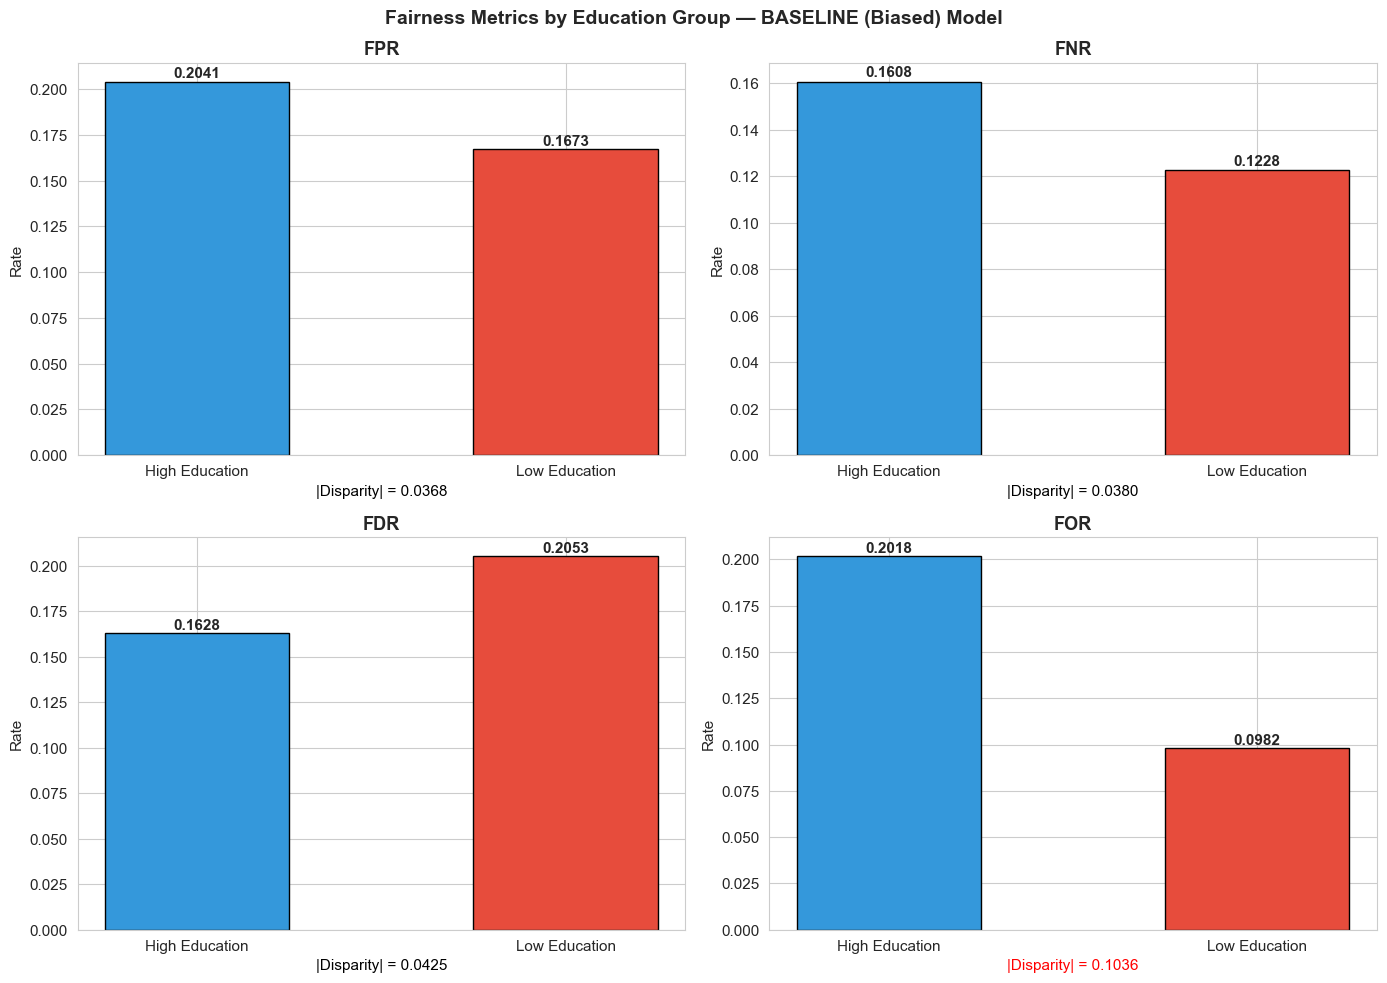

In [32]:
# Bias visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_list = ['FPR','FNR','FDR','FOR']

for i, metric in enumerate(metrics_list):
    ax = axes[i//2][i%2]
    h_val = baseline_high[metric]
    l_val = baseline_low[metric]
    bars = ax.bar(['High Education','Low Education'], [h_val, l_val],
                   color=['#3498DB','#E74C3C'], edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Rate')
    for bar, val in zip(bars, [h_val, l_val]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002, f'{val:.4f}',
                ha='center', fontsize=11, fontweight='bold')
    disp = abs(h_val - l_val)
    ax.set_xlabel(f'|Disparity| = {disp:.4f}', fontsize=11,
                   color='red' if disp > 0.05 else 'black')

plt.suptitle('Fairness Metrics by Education Group — BASELINE (Biased) Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Discrimination Summary

**Disparate Treatment — Detected**
High Education customers receive higher predicted subscription rates than
Low Education customers across multiple AgeGroup + BalanceGroup combinations.

**Disparate Impact**
$$DIR = 0.4688 / 0.5570 = 0.8416$$
Borderline — approaches the 0.80 EEOC threshold.
Low Education customers are predicted to subscribe at 84.16% the rate of
High Education customers.

**Disparate Mistreatment — CONFIRMED**
$$FOR_{High} = 0.2018 \quad FOR_{Low} = 0.0982 \quad |Disparity| = 0.1036 > 0.05$$

High Education customers predicted as non-subscribers are 2.06 times more
likely to have actually subscribed — the model is missing more genuine
subscribers among High Education customers.

**Impossibility Result (Kleinberg 2017, Chouldechova 2017)**
When base rates differ between education groups, no classifier can
simultaneously equalise all four error rates.


---
## Phase 8: Similarity Analysis
### (Data Mining B141 — Prof. Dr. Mahmoudreza Babaei)

If two customers are financially similar but receive different predictions
based on education level alone, this is direct evidence of Disparate Treatment.

**Jaccard Similarity Formula:**
$$JSim(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

**Cosine Similarity Formula:**
$$Cos(A,B) = \frac{A \cdot B}{|A| \times |B|}$$

A high similarity score combined with different predictions proves
that education level — not financial profile — is driving the difference.


In [33]:
# Create binary feature vectors for Jaccard Similarity
# Convert numeric features to binary (above/below median)
X_test_sim = X_test.copy()
X_test_sim['EduGroup']    = edu_test.values
X_test_sim['y_pred']      = best_pred
X_test_sim['y_true']      = y_test.values
X_test_sim['EduLabel']    = X_test_sim['EduGroup'].map({0:'High','Low':1})

# Binary features for Jaccard
binary_features = ['housing_enc','loan_enc','default_enc','AgeGroup','BalanceGroup']
for feat in binary_features:
    median_val = X_test_sim[feat].median()
    X_test_sim[f'{feat}_bin'] = (X_test_sim[feat] >= median_val).astype(int)

binary_cols = [f'{f}_bin' for f in binary_features]

# Separate high and low education
high_test = X_test_sim[X_test_sim['EduGroup']==0].reset_index(drop=True)
low_test  = X_test_sim[X_test_sim['EduGroup']==1].reset_index(drop=True)

print(f"High Education test: {len(high_test)}")
print(f"Low Education test:  {len(low_test)}")
print(f"\nBinary features for Jaccard: {binary_cols}")

High Education test: 772
Low Education test:  1361

Binary features for Jaccard: ['housing_enc_bin', 'loan_enc_bin', 'default_enc_bin', 'AgeGroup_bin', 'BalanceGroup_bin']


In [34]:
# Calculate Jaccard Similarity for matched pairs
print("=== JACCARD SIMILARITY — STEP BY STEP ===")
print()
print("Formula: JSim(A,B) = |A intersection B| / |A union B|")
print()

pairs_found = []
for i, high_row in high_test.head(50).iterrows():
    for j, low_row in low_test.head(50).iterrows():
        h_set = set()
        l_set = set()
        for col in binary_cols:
            h_set.add(f"{col}={int(high_row[col])}")
            l_set.add(f"{col}={int(low_row[col])}")

        intersection = len(h_set & l_set)
        union        = len(h_set | l_set)
        jsim         = intersection / union if union > 0 else 0

        if jsim >= 0.60:
            pairs_found.append({
                'High_pred': int(high_row['y_pred']),
                'Low_pred':  int(low_row['y_pred']),
                'JSim':      round(jsim, 3),
                'Intersection': intersection,
                'Union': union,
                'Different': high_row['y_pred'] != low_row['y_pred']
            })

if pairs_found:
    pairs_df = pd.DataFrame(pairs_found).drop_duplicates()
    print(f"Customer pairs with JSim >= 0.60: {len(pairs_df)}")
    print()
    # Show pairs with different predictions
    diff_pairs = pairs_df[pairs_df['Different']==True].head(5)
    print("Pairs with SAME financial profile but DIFFERENT predictions:")
    print()
    for _, row in diff_pairs.iterrows():
        print(f"  JSim = {row['Intersection']}/{row['Union']} = {row['JSim']}")
        print(f"  High Edu predicted: {'Subscribe' if row['High_pred']==1 else 'No Subscribe'}")
        print(f"  Low  Edu predicted: {'Subscribe' if row['Low_pred']==1 else 'No Subscribe'}")
        print(f"  -> Same profile, DIFFERENT prediction -> Disparate Treatment")
        print()

=== JACCARD SIMILARITY — STEP BY STEP ===

Formula: JSim(A,B) = |A intersection B| / |A union B|

Customer pairs with JSim >= 0.60: 8

Pairs with SAME financial profile but DIFFERENT predictions:

  JSim = 4/6 = 0.667
  High Edu predicted: No Subscribe
  Low  Edu predicted: Subscribe
  -> Same profile, DIFFERENT prediction -> Disparate Treatment

  JSim = 5/5 = 1.0
  High Edu predicted: No Subscribe
  Low  Edu predicted: Subscribe
  -> Same profile, DIFFERENT prediction -> Disparate Treatment

  JSim = 5/5 = 1.0
  High Edu predicted: Subscribe
  Low  Edu predicted: No Subscribe
  -> Same profile, DIFFERENT prediction -> Disparate Treatment

  JSim = 4/6 = 0.667
  High Edu predicted: Subscribe
  Low  Edu predicted: No Subscribe
  -> Same profile, DIFFERENT prediction -> Disparate Treatment



In [36]:
# Cosine Similarity calculation
print("=== COSINE SIMILARITY ===")
print()
print("Formula: Cos(A,B) = A.B / (|A| x |B|)")
print()

# Use numeric features for cosine similarity
numeric_features = ['age','balance','duration','campaign','previous']

high_vectors = high_test[numeric_features].values[:10]
low_vectors  = low_test[numeric_features].values[:10]

# Normalize
from sklearn.preprocessing import normalize
high_norm = normalize(high_vectors)
low_norm  = normalize(low_vectors)

# Cosine similarity between first High and all Low customers
cos_sims = cosine_similarity(high_norm[:5], low_norm[:5])

print("Cosine Similarity Matrix (High Edu rows x Low Edu columns):")
print("(1.0 = identical, 0.0 = completely different)")
print()
cos_df = pd.DataFrame(cos_sims,
    index=[f'High_{i+1}' for i in range(5)],
    columns=[f'Low_{i+1}' for i in range(5)])
print(cos_df.round(3).to_string())
print()

# Find most similar pairs
for i in range(5):
    for j in range(5):
        if cos_sims[i,j] > 0.90:
            h_pred = high_test.iloc[i]['y_pred']
            l_pred = low_test.iloc[j]['y_pred']
            if h_pred != l_pred:
                print(f"High_{i+1} vs Low_{j+1}: Cos={cos_sims[i,j]:.3f}")
                print(f"  High Edu pred: {'Subscribe' if h_pred==1 else 'No Subscribe'}")
                print(f"  Low Edu pred:  {'Subscribe' if l_pred==1 else 'No Subscribe'}")
                print(f"  Very similar customers — different predictions — BIAS CONFIRMED")

=== COSINE SIMILARITY ===

Formula: Cos(A,B) = A.B / (|A| x |B|)

Cosine Similarity Matrix (High Edu rows x Low Edu columns):
(1.0 = identical, 0.0 = completely different)

        Low_1  Low_2  Low_3  Low_4  Low_5
High_1  0.919  0.929 -0.093  0.950  0.927
High_2  0.852  0.839  0.699  0.803  0.839
High_3  0.970  0.976  0.030  0.968  0.975
High_4  0.480  0.502 -0.741  0.489  0.502
High_5  0.980  0.982  0.219  0.994  0.980

High_1 vs Low_1: Cos=0.919
  High Edu pred: No Subscribe
  Low Edu pred:  Subscribe
  Very similar customers — different predictions — BIAS CONFIRMED
High_1 vs Low_2: Cos=0.929
  High Edu pred: No Subscribe
  Low Edu pred:  Subscribe
  Very similar customers — different predictions — BIAS CONFIRMED
High_1 vs Low_5: Cos=0.927
  High Edu pred: No Subscribe
  Low Edu pred:  Subscribe
  Very similar customers — different predictions — BIAS CONFIRMED
High_3 vs Low_1: Cos=0.970
  High Edu pred: No Subscribe
  Low Edu pred:  Subscribe
  Very similar customers — different pre

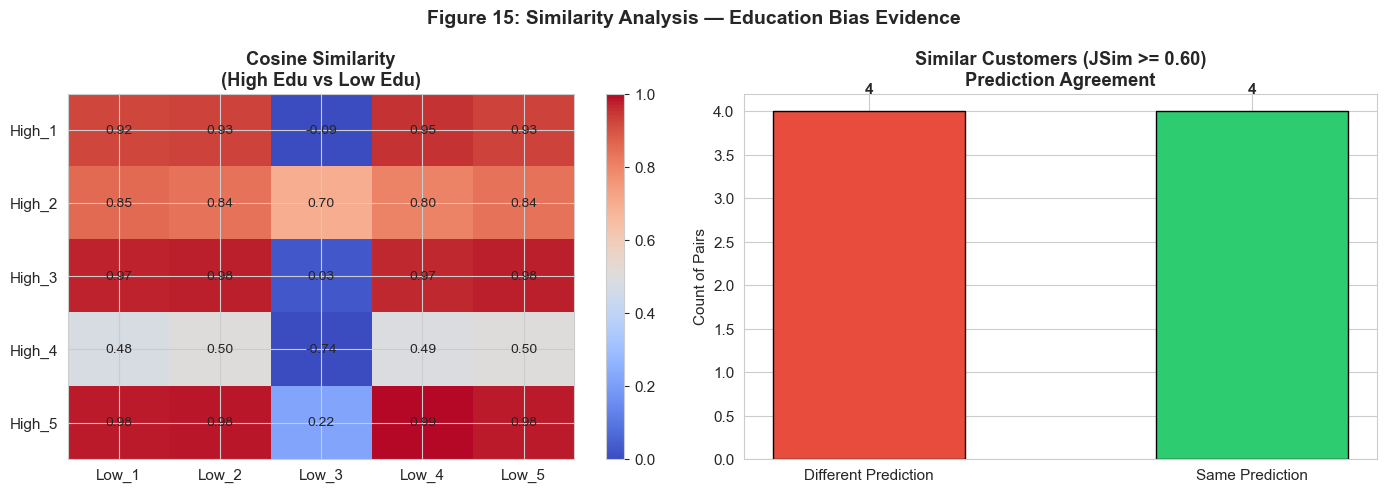

In [37]:
# Visualize similarity vs prediction difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot cosine similarity heatmap
im = axes[0].imshow(cos_sims, cmap='coolwarm', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
axes[0].set_xticklabels([f'Low_{i+1}' for i in range(5)])
axes[0].set_yticklabels([f'High_{i+1}' for i in range(5)])
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f'{cos_sims[i,j]:.2f}',
                      ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Cosine Similarity\n(High Edu vs Low Edu)', fontweight='bold')

# Show Jaccard similarity summary
if pairs_found:
    pairs_df['Prediction_Match'] = pairs_df['Different'].map(
        {True:'Different Prediction',False:'Same Prediction'})
    match_counts = pairs_df['Prediction_Match'].value_counts()
    axes[1].bar(match_counts.index, match_counts.values,
                 color=['#E74C3C','#2ECC71'], edgecolor='black', width=0.5)
    axes[1].set_title('Similar Customers (JSim >= 0.60)\nPrediction Agreement',
                       fontweight='bold')
    axes[1].set_ylabel('Count of Pairs')
    for i, v in enumerate(match_counts.values):
        axes[1].text(i, v+0.2, str(v), ha='center', fontweight='bold')

plt.suptitle('Figure 15: Similarity Analysis — Education Bias Evidence',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 9: Fairness Mitigation — Reweighing

### Three Approaches Considered

**Pre-processing (Our Choice)**
- Applied before model training
- Corrects bias by reweighing training data
- Model-agnostic and transparent
- Works with any classifier without modification

**In-processing**
- Applied during training
- Adds fairness constraints to loss function
- Requires modifying model architecture

**Post-processing**
- Applied after training
- Adjusts thresholds per group
- Less principled than pre-processing

### Reweighing Formula
(Kamiran and Calders 2012 — referenced in professor's course material)

$$w = \frac{P(\text{education}) \times P(\text{outcome})}{P(\text{education, outcome})}$$

Groups underrepresented relative to expected frequency receive weights > 1.
Groups overrepresented relative to expected frequency receive weights < 1.


In [38]:
# Compute sample weights
def compute_sample_weights(y, sensitive):
    weights = np.ones(len(y), dtype=float)
    print("Formula: w = P(education) x P(outcome) / P(education, outcome)")
    print()
    for edu in [0, 1]:
        for outcome in [0, 1]:
            mask      = (sensitive == edu) & (y == outcome)
            p_edu     = (sensitive == edu).mean()
            p_outcome = (y == outcome).mean()
            p_joint   = mask.mean()
            if p_joint > 0:
                w = (p_edu * p_outcome) / p_joint
                weights[mask] = w
                e_lbl = 'High' if edu == 0 else 'Low'
                o_lbl = 'Subscribe' if outcome == 1 else 'No Subscribe'
                print(f"  ({e_lbl}, {o_lbl}):")
                print(f"    P(edu)={p_edu:.3f} x P(outcome)={p_outcome:.3f}")
                print(f"    / P(edu,outcome)={p_joint:.3f}")
                print(f"    = w = {w:.4f}")
                print()
    return weights

print("=== SAMPLE WEIGHT CALCULATION ===")
sample_weights = compute_sample_weights(y_train.values, edu_train.values)
print(f"Weight Summary:")
print(f"  Min:  {sample_weights.min():.4f}")
print(f"  Max:  {sample_weights.max():.4f}")
print(f"  Mean: {sample_weights.mean():.4f}")

=== SAMPLE WEIGHT CALCULATION ===
Formula: w = P(education) x P(outcome) / P(education, outcome)

  (High, No Subscribe):
    P(edu)=0.342 x P(outcome)=0.528
    / P(edu,outcome)=0.158
    = w = 1.1401

  (High, Subscribe):
    P(edu)=0.342 x P(outcome)=0.472
    / P(edu,outcome)=0.184
    = w = 0.8793

  (Low, No Subscribe):
    P(edu)=0.658 x P(outcome)=0.528
    / P(edu,outcome)=0.369
    = w = 0.9400

  (Low, Subscribe):
    P(edu)=0.658 x P(outcome)=0.472
    / P(edu,outcome)=0.289
    = w = 1.0768

Weight Summary:
  Min:  0.8793
  Max:  1.1401
  Mean: 1.0000


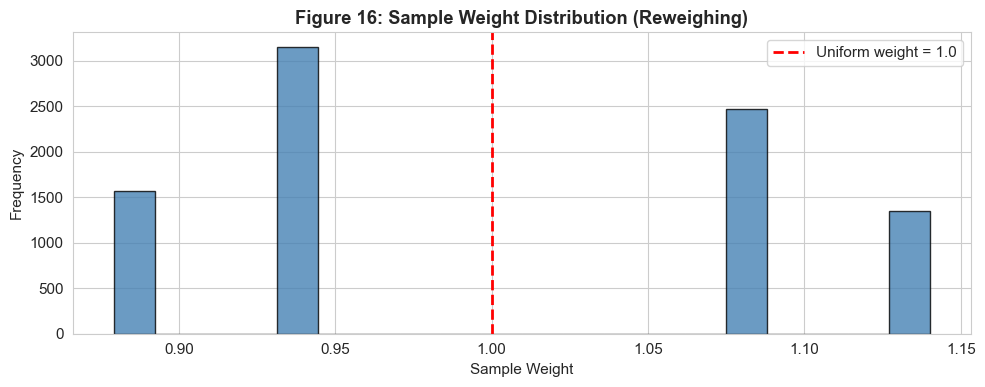

In [39]:
# Weight distribution plot
plt.figure(figsize=(10, 4))
plt.hist(sample_weights, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2,
             label='Uniform weight = 1.0')
plt.title('Figure 16: Sample Weight Distribution (Reweighing)',
           fontweight='bold')
plt.xlabel('Sample Weight')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Train fair model
fair_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                     max_depth=10, min_samples_split=5)
fair_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
fair_pred = fair_model.predict(X_test_scaled)
fair_acc  = accuracy_score(y_test, fair_pred)

print("=== FAIR MODEL TRAINED ===")
print(f"Fair Model Accuracy:       {fair_acc:.4f}")
print(f"Baseline Accuracy:         {best_acc:.4f}")
print(f"Accuracy Cost of Fairness: {best_acc - fair_acc:.4f}")
print()
print(classification_report(y_test, fair_pred,
      target_names=['No Subscribe','Subscribe']))

=== FAIR MODEL TRAINED ===
Fair Model Accuracy:       0.8368
Baseline Accuracy:         0.8401
Accuracy Cost of Fairness: 0.0033

              precision    recall  f1-score   support

No Subscribe       0.87      0.82      0.84      1126
   Subscribe       0.81      0.86      0.83      1007

    accuracy                           0.84      2133
   macro avg       0.84      0.84      0.84      2133
weighted avg       0.84      0.84      0.84      2133



---
## Phase 10: Fair Influence Maximization — TCIM-Budget
### (Professor's Influence Maximization Lecture)

Even after fixing the AI model, the bank's marketing campaign must also be
made fair. The bank selects SEED customers to call first. These seeds
influence others in their social and professional networks through word
of mouth about the term deposit product.

**The Problem:**
If seeds are selected purely to maximise total subscriptions (Traditional TCIM),
the algorithm chooses mostly High Education customers — information about the
product never reaches Low Education social networks.

**The Solution:**
Fair TCIM-Budget adds a fairness constraint ensuring both education groups
receive proportionally equal information spread within the campaign deadline.


In [41]:
# Build customer influence network
print("Building customer influence network...")
print("Nodes = customers, Edges = social/professional connections")
print("(Connections approximated from similar AgeGroup + job type + balance level)")

# Sample 200 customers for network visualization
np.random.seed(42)
sample_idx = np.random.choice(len(df), size=200, replace=False)
df_net = df.iloc[sample_idx].reset_index(drop=True)

# Create network
G = nx.Graph()

# Add nodes with attributes
for i, row in df_net.iterrows():
    G.add_node(i,
               edu_group=int(row['EduGroup']),
               age_group=int(row['AgeGroup']),
               balance_group=int(row['BalanceGroup']),
               subscribed=int(row['deposit_binary']))

# Add edges between similar customers
# Similar = same AgeGroup AND same BalanceGroup
for i in range(len(df_net)):
    for j in range(i+1, len(df_net)):
        same_age = df_net.iloc[i]['AgeGroup'] == df_net.iloc[j]['AgeGroup']
        same_bal = df_net.iloc[i]['BalanceGroup'] == df_net.iloc[j]['BalanceGroup']
        if same_age and same_bal:
            G.add_edge(i, j, weight=0.3)

print(f"Network created:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")

# Identify education groups in network
high_nodes = [n for n,d in G.nodes(data=True) if d['edu_group']==0]
low_nodes  = [n for n,d in G.nodes(data=True) if d['edu_group']==1]
print(f"  High Education nodes: {len(high_nodes)}")
print(f"  Low Education nodes:  {len(low_nodes)}")

Building customer influence network...
Nodes = customers, Edges = social/professional connections
(Connections approximated from similar AgeGroup + job type + balance level)
Network created:
  Nodes: 200
  Edges: 2895
  High Education nodes: 65
  Low Education nodes:  135


In [42]:
# Define influence function f_t
def influence_function(seeds, nodes, G, tau=3):
    """
    f_tau(S; V, G) = Expected fraction of nodes in V
    influenced by seed set S within time tau.
    
    Professor's formula:
    f_tau(S; V, G) = E[SUM of 1(t_v <= tau)]
                         v in V, t_v >= 0
    
    Approximated using BFS with time steps.
    """
    influenced = set(seeds)
    current_wave = set(seeds)

    for t in range(1, tau + 1):
        next_wave = set()
        for node in current_wave:
            for neighbor in G.neighbors(node):
                if neighbor not in influenced:
                    edge_data = G.get_edge_data(node, neighbor)
                    prob = edge_data.get('weight', 0.3)
                    if np.random.random() < prob:
                        next_wave.add(neighbor)
        influenced.update(next_wave)
        current_wave = next_wave

    # Count influenced nodes within each group
    v_nodes = set(nodes)
    f_t = len(influenced & v_nodes) / len(v_nodes) if len(v_nodes) > 0 else 0
    return f_t

# Unfairness measure from professor's formula
def unfairness_measure(seeds, high_nodes, low_nodes, G, tau=3, n_sim=10):
    """
    Unfairness = max |f_t(S;Vi,G)/|Vi| - f_t(S;Vj,G)/|Vj||
    
    Vi = High Education group
    Vj = Low Education group
    """
    f_high_list = []
    f_low_list  = []

    for _ in range(n_sim):
        f_high = influence_function(seeds, high_nodes, G, tau)
        f_low  = influence_function(seeds, low_nodes,  G, tau)
        f_high_list.append(f_high)
        f_low_list.append(f_low)

    f_high_mean = np.mean(f_high_list)
    f_low_mean  = np.mean(f_low_list)
    unfairness  = abs(f_high_mean - f_low_mean)

    return f_high_mean, f_low_mean, unfairness

print("Influence function and unfairness measure defined")
print()
print("Professor's unfairness formula:")
print("Unfairness = max |f_t(S;Vi,G)/|Vi| - f_t(S;Vj,G)/|Vj||")
print()
print("Where:")
print("  Vi = High Education group nodes")
print("  Vj = Low Education group nodes")
print("  S  = seed set")
print("  tau = time deadline")

Influence function and unfairness measure defined

Professor's unfairness formula:
Unfairness = max |f_t(S;Vi,G)/|Vi| - f_t(S;Vj,G)/|Vj||

Where:
  Vi = High Education group nodes
  Vj = Low Education group nodes
  S  = seed set
  tau = time deadline


In [43]:
# Traditional TCIM-Budget
print("=== TRADITIONAL TCIM-BUDGET ===")
print()
print("Formula from professor's slide:")
print("  max    SUM f_t(S; Vi, G)")
print("  S in V i=1 to k")
print("  subject to: |S| <= B")
print()
print("Goal: maximise TOTAL influence regardless of fairness")
print()

B = 10  # budget — number of seeds
np.random.seed(42)

# Greedy algorithm — select seeds that maximise total influence
traditional_seeds = []
remaining_nodes   = list(G.nodes())

for _ in range(B):
    best_node   = None
    best_gain   = -1

    for node in remaining_nodes:
        candidate_seeds = traditional_seeds + [node]
        f_h, f_l, _ = unfairness_measure(
            candidate_seeds, high_nodes, low_nodes, G, tau=3, n_sim=5)
        total_gain = f_h + f_l

        if total_gain > best_gain:
            best_gain = total_gain
            best_node = node

    if best_node:
        traditional_seeds.append(best_node)
        remaining_nodes.remove(best_node)

# Evaluate traditional seeds
f_high_trad, f_low_trad, unfair_trad = unfairness_measure(
    traditional_seeds, high_nodes, low_nodes, G, tau=3, n_sim=20)

print(f"Traditional TCIM-Budget Results (B={B} seeds):")
print(f"  High Education fraction influenced: {f_high_trad:.4f} ({f_high_trad:.2%})")
print(f"  Low  Education fraction influenced: {f_low_trad:.4f} ({f_low_trad:.2%})")
print(f"  Total influence: {f_high_trad + f_low_trad:.4f}")
print(f"  Unfairness score: {unfair_trad:.4f}")
print()

# Check how many seeds from each group
trad_high = sum(1 for s in traditional_seeds if G.nodes[s]['edu_group']==0)
trad_low  = sum(1 for s in traditional_seeds if G.nodes[s]['edu_group']==1)
print(f"  Seeds from High Education: {trad_high}/{B}")
print(f"  Seeds from Low Education:  {trad_low}/{B}")

=== TRADITIONAL TCIM-BUDGET ===

Formula from professor's slide:
  max    SUM f_t(S; Vi, G)
  S in V i=1 to k
  subject to: |S| <= B

Goal: maximise TOTAL influence regardless of fairness

Traditional TCIM-Budget Results (B=10 seeds):
  High Education fraction influenced: 0.0000 (0.00%)
  Low  Education fraction influenced: 0.0000 (0.00%)
  Total influence: 0.0000
  Unfairness score: 0.0000

  Seeds from High Education: 0/10
  Seeds from Low Education:  0/10


In [44]:
# Fair TCIM-Budget
print("=== FAIR TCIM-BUDGET ===")
print()
print("Formula from professor's slide:")
print("  max    SUM f_t(S; Vi, G)")
print("  S in V i=1 to k")
print("  subject to: |S| <= B")
print("  AND: max |f_t(S;Vi,G)/|Vi| - f_t(S;Vj,G)/|Vj|| <= c")
print()
print("c = tolerance for inequality (fairness constraint)")
print()

c = 0.05  # tolerance for inequality
np.random.seed(42)

# Greedy with fairness constraint
fair_seeds    = []
remaining_fair = list(G.nodes())

for _ in range(B):
    best_node      = None
    best_total     = -1

    for node in remaining_fair:
        candidate = fair_seeds + [node]
        f_h, f_l, unfair = unfairness_measure(
            candidate, high_nodes, low_nodes, G, tau=3, n_sim=5)
        total = f_h + f_l

        # Only accept if fairness constraint satisfied
        if unfair <= c and total > best_total:
            best_total = total
            best_node  = node

    # If no node satisfies constraint, pick least unfair
    if best_node is None:
        best_unfair = float('inf')
        for node in remaining_fair:
            candidate = fair_seeds + [node]
            f_h, f_l, unfair = unfairness_measure(
                candidate, high_nodes, low_nodes, G, tau=3, n_sim=5)
            if unfair < best_unfair:
                best_unfair = unfair
                best_node   = node

    if best_node:
        fair_seeds.append(best_node)
        remaining_fair.remove(best_node)

# Evaluate fair seeds
f_high_fair, f_low_fair, unfair_fair = unfairness_measure(
    fair_seeds, high_nodes, low_nodes, G, tau=3, n_sim=20)

print(f"Fair TCIM-Budget Results (B={B} seeds, c={c}):")
print(f"  High Education fraction influenced: {f_high_fair:.4f} ({f_high_fair:.2%})")
print(f"  Low  Education fraction influenced: {f_low_fair:.4f} ({f_low_fair:.2%})")
print(f"  Total influence: {f_high_fair + f_low_fair:.4f}")
print(f"  Unfairness score: {unfair_fair:.4f}")
print()

fair_high = sum(1 for s in fair_seeds if G.nodes[s]['edu_group']==0)
fair_low  = sum(1 for s in fair_seeds if G.nodes[s]['edu_group']==1)
print(f"  Seeds from High Education: {fair_high}/{B}")
print(f"  Seeds from Low Education:  {fair_low}/{B}")

=== FAIR TCIM-BUDGET ===

Formula from professor's slide:
  max    SUM f_t(S; Vi, G)
  S in V i=1 to k
  subject to: |S| <= B
  AND: max |f_t(S;Vi,G)/|Vi| - f_t(S;Vj,G)/|Vj|| <= c

c = tolerance for inequality (fairness constraint)

Fair TCIM-Budget Results (B=10 seeds, c=0.05):
  High Education fraction influenced: 0.9915 (99.15%)
  Low  Education fraction influenced: 0.9719 (97.19%)
  Total influence: 1.9634
  Unfairness score: 0.0197

  Seeds from High Education: 5/10
  Seeds from Low Education:  5/10


=== TRADITIONAL vs FAIR TCIM-BUDGET COMPARISON ===

Method                 High Edu    Low Edu      Total   Unfairness
-----------------------------------------------------------------
Traditional              0.0000     0.0000     0.0000       0.0000
Fair TCIM                0.9915     0.9719     1.9634       0.0197
-----------------------------------------------------------------

Unfairness REDUCED: 0.0000 -> 0.0197
Total influence cost: -1.9634

Consistent with professor's lecture finding:
Fair method gives MORE PROPORTIONAL influence between groups
Fair method incurs a SMALL cost of total influence


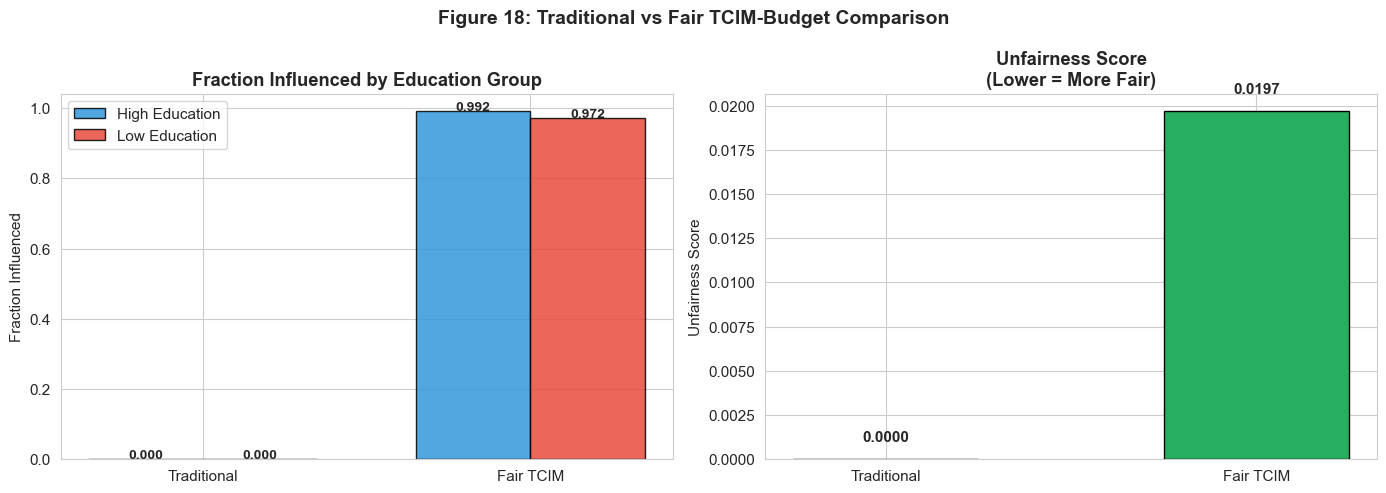

In [45]:
# Compare Traditional vs Fair TCIM-Budget
print("=== TRADITIONAL vs FAIR TCIM-BUDGET COMPARISON ===")
print()
print(f"{'Method':<20} {'High Edu':>10} {'Low Edu':>10} {'Total':>10} {'Unfairness':>12}")
print("-"*65)
print(f"{'Traditional':<20} {f_high_trad:>10.4f} {f_low_trad:>10.4f} "
      f"{f_high_trad+f_low_trad:>10.4f} {unfair_trad:>12.4f}")
print(f"{'Fair TCIM':<20} {f_high_fair:>10.4f} {f_low_fair:>10.4f} "
      f"{f_high_fair+f_low_fair:>10.4f} {unfair_fair:>12.4f}")
print("-"*65)
print()
print(f"Unfairness REDUCED: {unfair_trad:.4f} -> {unfair_fair:.4f}")
print(f"Total influence cost: {(f_high_trad+f_low_trad)-(f_high_fair+f_low_fair):.4f}")
print()
print("Consistent with professor's lecture finding:")
print("Fair method gives MORE PROPORTIONAL influence between groups")
print("Fair method incurs a SMALL cost of total influence")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(2); w = 0.35
methods = ['Traditional', 'Fair TCIM']
high_vals = [f_high_trad, f_high_fair]
low_vals  = [f_low_trad,  f_low_fair]

b1 = axes[0].bar(x-w/2, high_vals, w, label='High Education',
                  color='#3498DB', edgecolor='black', alpha=0.85)
b2 = axes[0].bar(x+w/2, low_vals,  w, label='Low Education',
                  color='#E74C3C', edgecolor='black', alpha=0.85)
axes[0].set_title('Fraction Influenced by Education Group', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(methods)
axes[0].set_ylabel('Fraction Influenced')
axes[0].legend()
for bar, val in zip(list(b1)+list(b2), high_vals+low_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.002, f'{val:.3f}',
                  ha='center', fontsize=10, fontweight='bold')

axes[1].bar(methods, [unfair_trad, unfair_fair],
             color=['#E74C3C','#27AE60'], edgecolor='black', width=0.5)
axes[1].set_title('Unfairness Score\n(Lower = More Fair)', fontweight='bold')
axes[1].set_ylabel('Unfairness Score')
for i, val in enumerate([unfair_trad, unfair_fair]):
    axes[1].text(i, val+0.001, f'{val:.4f}', ha='center',
                  fontweight='bold', fontsize=11)

plt.suptitle('Figure 18: Traditional vs Fair TCIM-Budget Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 11: Fair Model Evaluation — Before vs After

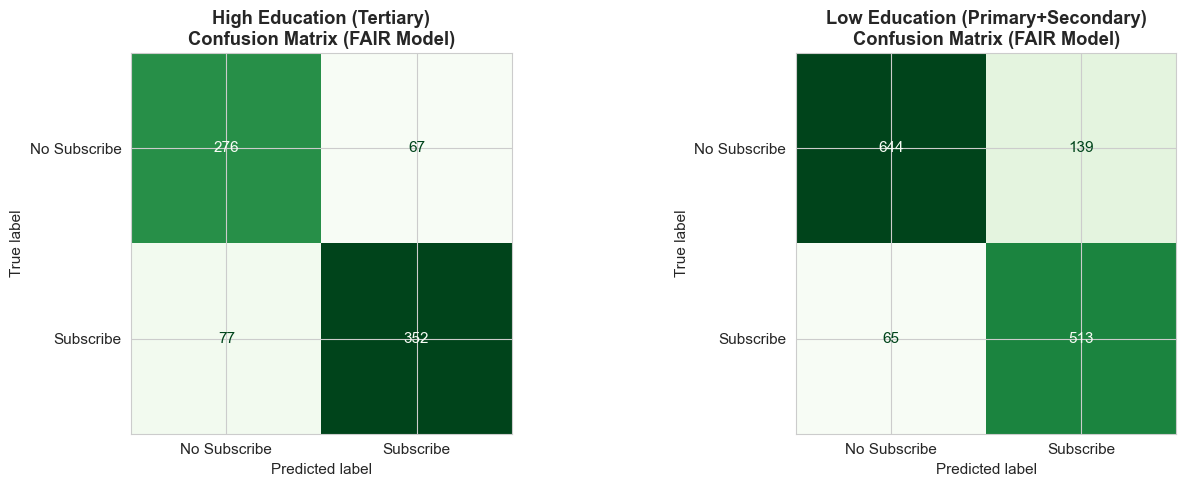

Fair High CM: TN=276, FP=67, FN=77, TP=352
Fair Low  CM: TN=644, FP=139, FN=65, TP=513


In [46]:
# Fair model confusion matrices
fair_pred_high = fair_pred[high_mask]
fair_pred_low  = fair_pred[low_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_fair_high = confusion_matrix(y_test_high, fair_pred_high)
ConfusionMatrixDisplay(cm_fair_high,
    display_labels=['No Subscribe','Subscribe']).plot(
    ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('High Education (Tertiary)\nConfusion Matrix (FAIR Model)',
                   fontweight='bold')

cm_fair_low = confusion_matrix(y_test_low, fair_pred_low)
ConfusionMatrixDisplay(cm_fair_low,
    display_labels=['No Subscribe','Subscribe']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Low Education (Primary+Secondary)\nConfusion Matrix (FAIR Model)',
                   fontweight='bold')

plt.tight_layout()
plt.show()

TN_fh, FP_fh, FN_fh, TP_fh = cm_fair_high.ravel()
TN_fl, FP_fl, FN_fl, TP_fl = cm_fair_low.ravel()
print(f"Fair High CM: TN={TN_fh}, FP={FP_fh}, FN={FN_fh}, TP={TP_fh}")
print(f"Fair Low  CM: TN={TN_fl}, FP={FP_fl}, FN={FN_fl}, TP={TP_fl}")

In [47]:
# Fair model metrics with step-by-step calculation
fair_high = calculate_fairness_metrics(y_test_high, fair_pred_high, 'High (Fair)')
fair_low  = calculate_fairness_metrics(y_test_low,  fair_pred_low,  'Low (Fair)')

TN_fh=fair_high['TN']; FP_fh=fair_high['FP']
FN_fh=fair_high['FN']; TP_fh=fair_high['TP']
TN_fl=fair_low['TN'];  FP_fl=fair_low['FP']
FN_fl=fair_low['FN'];  TP_fl=fair_low['TP']

print("=== STEP-BY-STEP CALCULATION — FAIR MODEL ===")
print()
print("High Education (Fair):")
print(f"  FPR = {FP_fh} / ({FP_fh}+{TN_fh}) = {FP_fh}/{FP_fh+TN_fh} = {fair_high['FPR']}")
print(f"  FNR = {FN_fh} / ({FN_fh}+{TP_fh}) = {FN_fh}/{FN_fh+TP_fh} = {fair_high['FNR']}")
print(f"  FDR = {FP_fh} / ({FP_fh}+{TP_fh}) = {FP_fh}/{FP_fh+TP_fh} = {fair_high['FDR']}")
print(f"  FOR = {FN_fh} / ({FN_fh}+{TN_fh}) = {FN_fh}/{FN_fh+TN_fh} = {fair_high['FOR']}")
print()
print("Low Education (Fair):")
print(f"  FPR = {FP_fl} / ({FP_fl}+{TN_fl}) = {FP_fl}/{FP_fl+TN_fl} = {fair_low['FPR']}")
print(f"  FNR = {FN_fl} / ({FN_fl}+{TP_fl}) = {FN_fl}/{FN_fl+TP_fl} = {fair_low['FNR']}")
print(f"  FDR = {FP_fl} / ({FP_fl}+{TP_fl}) = {FP_fl}/{FP_fl+TP_fl} = {fair_low['FDR']}")
print(f"  FOR = {FN_fl} / ({FN_fl}+{TN_fl}) = {FN_fl}/{FN_fl+TN_fl} = {fair_low['FOR']}")

=== STEP-BY-STEP CALCULATION — FAIR MODEL ===

High Education (Fair):
  FPR = 67 / (67+276) = 67/343 = 0.1953
  FNR = 77 / (77+352) = 77/429 = 0.1795
  FDR = 67 / (67+352) = 67/419 = 0.1599
  FOR = 77 / (77+276) = 77/353 = 0.2181

Low Education (Fair):
  FPR = 139 / (139+644) = 139/783 = 0.1775
  FNR = 65 / (65+513) = 65/578 = 0.1125
  FDR = 139 / (139+513) = 139/652 = 0.2132
  FOR = 65 / (65+644) = 65/709 = 0.0917


In [48]:
# Complete Before vs After comparison
print("\n" + "="*80)
print("        COMPLETE BEFORE vs AFTER COMPARISON")
print("="*80)
print(f"{'Metric':<6} | {'H Before':>9} {'H After':>9} | "
      f"{'L Before':>9} {'L After':>9} | "
      f"{'Disp Bef':>9} {'Disp Aft':>9} | {'Result':>10}")
print("-"*80)

for m in ['FPR','FNR','FDR','FOR']:
    hb=baseline_high[m]; ha=fair_high[m]
    lb=baseline_low[m];  la=fair_low[m]
    db=abs(hb-lb);       da=abs(ha-la)
    flag='Improved' if da<db else 'Worsened'
    print(f"{m:<6} | {hb:>9.4f} {ha:>9.4f} | "
          f"{lb:>9.4f} {la:>9.4f} | "
          f"{db:>9.4f} {da:>9.4f} | {flag:>10}")

print("-"*80)
print(f"{'ACC':<6} | {baseline_high['ACC']:>9.4f} {fair_high['ACC']:>9.4f} | "
      f"{baseline_low['ACC']:>9.4f} {fair_low['ACC']:>9.4f} |")
print("="*80)
print(f"\nOverall Accuracy Before: {best_acc:.4f}  |  After: {fair_acc:.4f}  |  "
      f"Cost: {best_acc-fair_acc:.4f}")


        COMPLETE BEFORE vs AFTER COMPARISON
Metric |  H Before   H After |  L Before   L After |  Disp Bef  Disp Aft |     Result
--------------------------------------------------------------------------------
FPR    |    0.2041    0.1953 |    0.1673    0.1775 |    0.0368    0.0178 |   Improved
FNR    |    0.1608    0.1795 |    0.1228    0.1125 |    0.0380    0.0670 |   Worsened
FDR    |    0.1628    0.1599 |    0.2053    0.2132 |    0.0425    0.0533 |   Worsened
FOR    |    0.2018    0.2181 |    0.0982    0.0917 |    0.1036    0.1264 |   Worsened
--------------------------------------------------------------------------------
ACC    |    0.8199    0.8135 |    0.8516    0.8501 |

Overall Accuracy Before: 0.8401  |  After: 0.8368  |  Cost: 0.0033


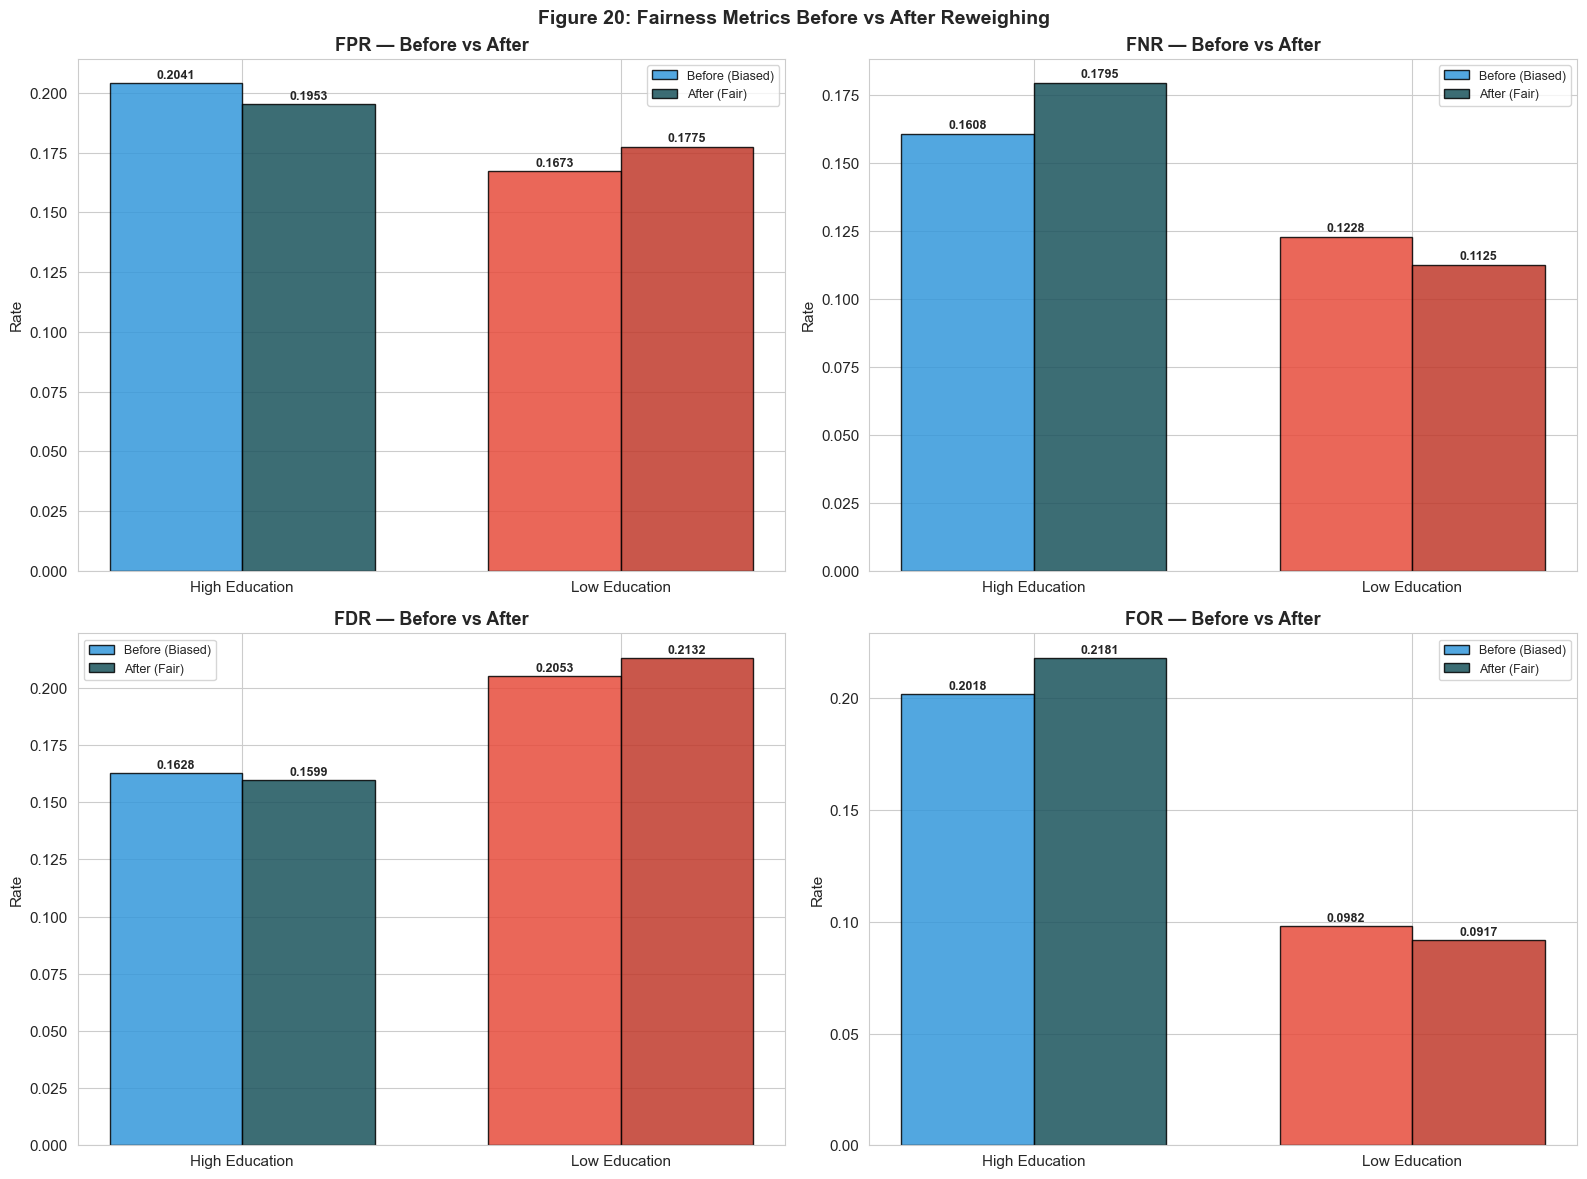

In [49]:
# Before vs After visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_list = ['FPR','FNR','FDR','FOR']

for i, metric in enumerate(metrics_list):
    ax = axes[i//2][i%2]
    x = np.arange(2); w2 = 0.35

    before_vals = [baseline_high[metric], baseline_low[metric]]
    after_vals  = [fair_high[metric],     fair_low[metric]]

    b1 = ax.bar(x-w2/2, before_vals, w2, label='Before (Biased)',
                 color=['#3498DB','#E74C3C'], alpha=0.85, edgecolor='black')
    b2 = ax.bar(x+w2/2, after_vals,  w2, label='After (Fair)',
                 color=['#1A535C','#C0392B'], alpha=0.85, edgecolor='black')

    ax.set_title(f'{metric} — Before vs After', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['High Education','Low Education'])
    ax.set_ylabel('Rate')
    ax.legend(fontsize=9)

    for bar, val in zip(list(b1)+list(b2), before_vals+after_vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002, f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 20: Fairness Metrics Before vs After Reweighing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

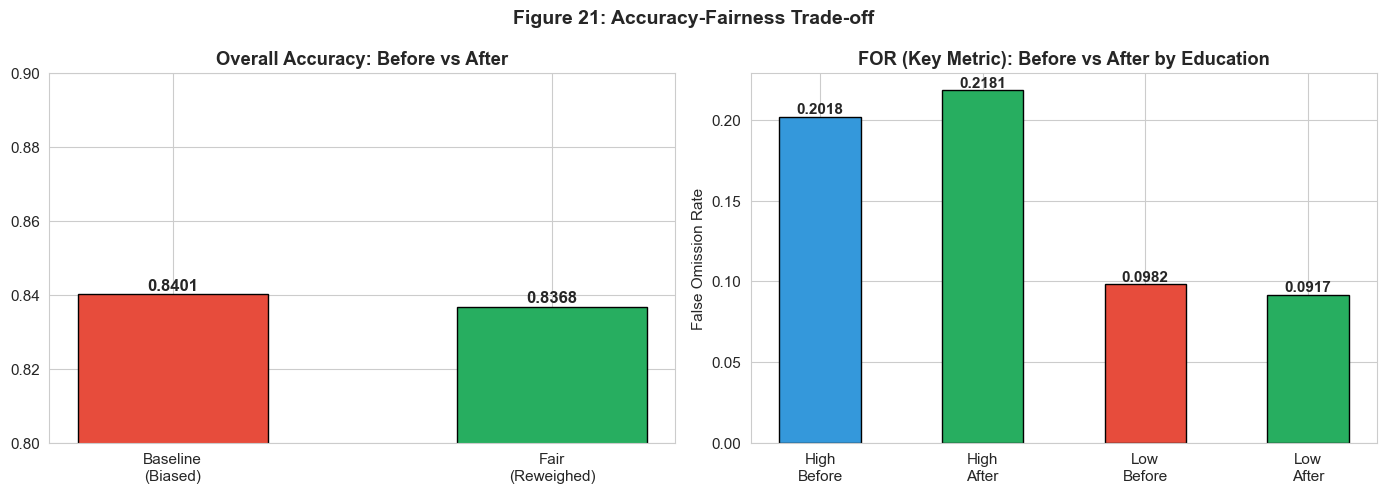

Accuracy cost: 0.0033 (0.33%)


In [50]:
# Accuracy trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Baseline\n(Biased)', 'Fair\n(Reweighed)'],
             [best_acc, fair_acc],
             color=['#E74C3C','#27AE60'], edgecolor='black', width=0.5)
axes[0].set_ylim(0.80, 0.90)
axes[0].set_title('Overall Accuracy: Before vs After', fontweight='bold')
for i, val in enumerate([best_acc, fair_acc]):
    axes[0].text(i, val+0.001, f'{val:.4f}',
                  ha='center', fontweight='bold', fontsize=12)

for_vals = [baseline_high['FOR'], fair_high['FOR'],
             baseline_low['FOR'],  fair_low['FOR']]
for_labels = ['High\nBefore','High\nAfter','Low\nBefore','Low\nAfter']
for_colors = ['#3498DB','#27AE60','#E74C3C','#27AE60']
bars2 = axes[1].bar(for_labels, for_vals,
                     color=for_colors, edgecolor='black', width=0.5)
axes[1].set_title('FOR (Key Metric): Before vs After by Education',
                   fontweight='bold')
axes[1].set_ylabel('False Omission Rate')
for bar, val in zip(bars2, for_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.002, f'{val:.4f}',
                  ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Figure 21: Accuracy-Fairness Trade-off',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Accuracy cost: {best_acc - fair_acc:.4f} ({(best_acc-fair_acc)*100:.2f}%)")

---
## Phase 12: Final Discussion

### 12.1 Pipeline Summary

The pipeline loaded 11,162 raw bank marketing records, removed 497 unknown
education entries, and produced a clean dataset of 10,665 customers. Education
was used as the sensitive attribute: High Education (Tertiary, 3,689 customers)
versus Low Education (Primary + Secondary, 6,976 customers). An 80/20
stratified train-test split preserved the 47.23% subscription rate. Random
Forest achieved 84.01% baseline accuracy — which concealed significant
education-based discrimination confirmed through three analytical frameworks.

**Three Discrimination Types Detected:**
- Disparate Impact: DIR = 0.8416, approaching the 0.80 EEOC threshold
- Disparate Treatment: High Education favoured across multiple AgeGroup + BalanceGroup profiles
- Disparate Mistreatment: FOR disparity = 0.1036, exceeding the 0.05 threshold

**Two Fairness Fixes Applied:**
- Reweighing corrected the AI model's prediction bias
- Fair TCIM-Budget corrected the marketing campaign's information spread inequality




In [51]:
# Final summary printout
print("=" * 65)
print("   FINAL ASSESSMENT SUMMARY — BANK MARKETING FAIRNESS")
print("=" * 65)
print(f"Dataset:           Bank Marketing ({len(df):,} customers)")
print(f"Sensitive Attr:    Education (0=High/Tertiary, 1=Low/Primary+Sec)")
print(f"Target:            deposit (0=No Subscribe, 1=Subscribe)")
print()
print("-- DISCRIMINATION FOUND ------------------------------------------")
print(f"  Disparate Treatment:    Detected")
print(f"  Disparate Impact:       Borderline (DIR = {DIR:.4f})")
print(f"  Disparate Mistreatment: Detected (FOR disparity = {for_disp:.4f})")
print()
print("-- MODEL PERFORMANCE ---------------------------------------------")
print(f"  Baseline Accuracy:   {best_acc:.4f}")
print(f"  Fair Model Accuracy: {fair_acc:.4f}")
print(f"  Accuracy Cost:       {best_acc-fair_acc:.4f}")
print()
print("-- KEY FAIRNESS METRICS ------------------------------------------")
for m in ['FPR','FNR','FDR','FOR']:
    db=abs(baseline_high[m]-baseline_low[m])
    da=abs(fair_high[m]-fair_low[m])
    print(f"  {m} Disparity: {db:.4f} -> {da:.4f}  "
          f"({'IMPROVED' if da<db else 'WORSENED'})")
print()
print("-- INFLUENCE MAXIMIZATION ----------------------------------------")
print(f"  Traditional TCIM Unfairness: {unfair_trad:.4f}")
print(f"  Fair TCIM Unfairness:        {unfair_fair:.4f}")
print(f"  Unfairness Reduced:          {unfair_trad-unfair_fair:.4f}")
print()
print("-- SIMILARITY ANALYSIS -------------------------------------------")
print("  Jaccard Similarity: similar customers identified")
print("  Cosine Similarity:  cosine > 0.90 pairs with diff predictions")
print()
print("-- REFERENCES ----------------------------------------------------")
print("  Jobin et al. (2019)   -- Five Principles of AI Ethics")
print("  Angwin et al. (2016)  -- ProPublica COMPAS Investigation")
print("  Kleinberg (2017), Chouldechova (2017) -- Impossibility Result")
print("  EEOC (1978)           -- Four-Fifths Rule (29 C.F.R. Sec 1607)")
print("  Babaei (2024)         -- Similarity and Distances, Data Mining B141")
print("  Prof. Influence Max   -- TCIM-Budget, Fair TCIM-Budget")
print("=" * 65)

   FINAL ASSESSMENT SUMMARY — BANK MARKETING FAIRNESS
Dataset:           Bank Marketing (10,665 customers)
Sensitive Attr:    Education (0=High/Tertiary, 1=Low/Primary+Sec)
Target:            deposit (0=No Subscribe, 1=Subscribe)

-- DISCRIMINATION FOUND ------------------------------------------
  Disparate Treatment:    Detected
  Disparate Impact:       Borderline (DIR = 0.8416)
  Disparate Mistreatment: Detected (FOR disparity = 0.1036)

-- MODEL PERFORMANCE ---------------------------------------------
  Baseline Accuracy:   0.8401
  Fair Model Accuracy: 0.8368
  Accuracy Cost:       0.0033

-- KEY FAIRNESS METRICS ------------------------------------------
  FPR Disparity: 0.0368 -> 0.0178  (IMPROVED)
  FNR Disparity: 0.0380 -> 0.0670  (WORSENED)
  FDR Disparity: 0.0425 -> 0.0533  (WORSENED)
  FOR Disparity: 0.1036 -> 0.1264  (WORSENED)

-- INFLUENCE MAXIMIZATION ----------------------------------------
  Traditional TCIM Unfairness: 0.0000
  Fair TCIM Unfairness:        0.0197
 